In [ ]:
import os
import pathlib

candidate_dirs = [
    pathlib.Path.cwd(),
    pathlib.Path.cwd() / '..' / 'discover' / 'data_acquiring',
    pathlib.Path.cwd() / 'option-c-trial-access' / 'discover' / 'data_acquiring',
]

for candidate in candidate_dirs:
    candidate = candidate.resolve()
    if (candidate / 'api_call_data_grabbing.ipynb').exists():
        os.chdir(candidate)
        break
else:
    raise FileNotFoundError('Could not locate option-c-trial-access/discover/data_acquiring.')

In [ ]:
import json
import os
import pathlib
import re
import sys
import time

# Ensure Windows Jupyter sessions launched from an unactivated conda kernel
# can still find this env's BLAS/DLL dependencies before NumPy imports.
# if os.name == "nt":
#     env_root = pathlib.Path(sys.executable).resolve().parent
#     dll_dirs = [
#         env_root,
#         env_root / "Library" / "bin",
#         env_root / "Scripts",
#         env_root / "DLLs",
#     ]
#     for dll_dir in dll_dirs:
#         if not dll_dir.exists():
#             continue
#         os.environ["PATH"] = f"{dll_dir};{os.environ.get('PATH', '')}"
#         if hasattr(os, "add_dll_directory"):
#             os.add_dll_directory(str(dll_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import requests
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

DOTENV_PATH = pathlib.Path("../../../.env")
load_dotenv(dotenv_path=DOTENV_PATH)

RAW = pathlib.Path("../../product/data/raw")
MOD = pathlib.Path("../../product/data/modified")
RESULTS = pathlib.Path("../results")
RAW.mkdir(parents=True, exist_ok=True)
MOD.mkdir(parents=True, exist_ok=True)
TEMP = MOD / "temp"
TEMP.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

CENSUS_KEY = os.getenv("CENSUS_API_KEY", "")
REQUEST_PAUSE_SEC = 0.2  # polite delay between API calls
PRODUCT_RESULTS = pathlib.Path("../../product/results")
PRODUCT_RESULTS.mkdir(parents=True, exist_ok=True)


def csvs_cached(*paths):
    """Return True if every path exists and is non-empty."""
    for p in paths:
        p = pathlib.Path(p)
        if not p.exists() or p.stat().st_size == 0:
            return False
    return True

US_STATE_ABBR = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
}

STATE_NAME_TO_ABBR = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

FIPS_TO_ABBR = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO", "09": "CT", "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

# Approximate state tile-grid positions for map-like choropleths without GIS dependencies.
STATE_TILE_POS = {
    "WA": (0, 0), "MT": (1, 0), "ND": (2, 0), "MN": (3, 0), "WI": (4, 0), "MI": (5, 0), "VT": (7, 0), "ME": (8, 0),
    "OR": (0, 1), "ID": (1, 1), "SD": (2, 1), "IA": (3, 1), "IL": (4, 1), "IN": (5, 1), "OH": (6, 1), "PA": (7, 1), "NY": (8, 1),
    "CA": (0, 2), "NV": (1, 2), "WY": (2, 2), "NE": (3, 2), "MO": (4, 2), "KY": (5, 2), "WV": (6, 2), "VA": (7, 2), "MD": (8, 2),
    "AZ": (1, 3), "UT": (2, 3), "CO": (3, 3), "KS": (4, 3), "AR": (5, 3), "TN": (6, 3), "NC": (7, 3), "SC": (8, 3), "DC": (9, 3),
    "NM": (2, 4), "OK": (4, 4), "LA": (5, 4), "MS": (6, 4), "AL": (7, 4), "GA": (8, 4),
    "TX": (4, 5), "FL": (9, 5),
    "AK": (0, 6), "HI": (1, 6),
    "NH": (7, 0), "MA": (8, 0), "CT": (8, 1), "RI": (8, 1), "NJ": (8, 2), "DE": (8, 2)
}


def normalize_state(value):
    if value is None:
        return None
    txt = re.sub(r"\s+", " ", str(value)).strip()
    if not txt:
        return None
    up = txt.upper()
    if up in US_STATE_ABBR:
        return up
    title = txt.title()
    return STATE_NAME_TO_ABBR.get(title)


def phase_group(value):
    if pd.isna(value):
        return "UNKNOWN"
    txt = str(value).strip()
    if not txt:
        return "UNKNOWN"
    parts = [p.strip() for p in txt.split(",") if p.strip()]
    if not parts:
        return "UNKNOWN"
    return parts[0].upper()


def tile_choropleth(df, value_col, title, cmap_name, out_name, vcenter=None):
    val_map = dict(zip(df["stateabbr"], df[value_col]))
    vals = np.array([v for v in val_map.values() if pd.notna(v)])

    if len(vals) == 0:
        print(f"No values available for {value_col}; skipping {title}.")
        return

    if vcenter is None:
        norm = mpl.colors.Normalize(vmin=float(np.nanmin(vals)), vmax=float(np.nanmax(vals)))
    else:
        norm = mpl.colors.TwoSlopeNorm(vmin=float(np.nanmin(vals)), vcenter=vcenter, vmax=float(np.nanmax(vals)))

    cmap = mpl.cm.get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=(12, 8))
    for st, (x, y) in STATE_TILE_POS.items():
        v = val_map.get(st, np.nan)
        color = "#eeeeee" if pd.isna(v) else cmap(norm(v))
        rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor="white", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, st, ha="center", va="center", fontsize=8)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(value_col)

    out_path = RESULTS / out_name
    product_out_path = PRODUCT_RESULTS / out_name
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    fig.savefig(product_out_path, dpi=200)
    plt.show()
    print("Saved figure:", out_path)
    print("Saved figure:", product_out_path)




def fetch_socrata_rows(url, where_clause=None, order_by=None, limit=10_000, timeout=60, sleep_sec=0.5):
    """Page through a Socrata endpoint using $limit/$offset and return all rows."""
    all_rows = []
    offset = 0
    while True:
        params = {"$limit": limit, "$offset": offset}
        if where_clause:
            params["$where"] = where_clause
        if order_by:
            params["$order"] = order_by
        batch = request_json(url, params=params, timeout=timeout)
        if not batch:
            break
        all_rows.extend(batch)
        if len(batch) < limit:
            break
        offset += limit
        time.sleep(sleep_sec)
    return all_rows
sns.set_theme(style="whitegrid")

def request_json(url, params=None, timeout=30):
    resp = requests.get(url, params=params, timeout=timeout)
    resp.raise_for_status()
    return resp.json()


def save_json(path, data):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)




def safe_percent(numerator, denominator):
    """Compute 100 * numerator / denominator, returning NaN where denominator <= 0."""
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")
    return np.where(den > 0, 100.0 * num / den, np.nan)


def safe_rate_per_100k(count, population):
    """Compute count per 100 000 population, returning NaN where population <= 0."""
    c = pd.to_numeric(count, errors="coerce")
    p = pd.to_numeric(population, errors="coerce")
    return np.where(p > 0, 1e5 * c / p, np.nan)

print("Raw dir:", RAW.resolve())
print("Modified dir:", MOD.resolve())
print("Results dir:", RESULTS.resolve())
print("Census API key present:", bool(CENSUS_KEY))

Raw dir: /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-c-trial-access/product/data/raw
Modified dir: /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-c-trial-access/product/data/modified
Results dir: /Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/option-c-trial-access/discover/results
Census API key present: True


In [ ]:
# Quick API version check for provenance tracking.
_CT_CSVS = [TEMP / f for f in ["ct_trials_flat.csv", "ct_sites_flat.csv", "ct_state_aggregates.csv", "ct_trial_state_pairs.csv"]]
if csvs_cached(*_CT_CSVS):
    print("[CACHE] CT.gov CSVs already cached; skipping version check.")
else:
    version_url = "https://clinicaltrials.gov/api/v2/version"
    version_payload = request_json(version_url, timeout=30)
    save_json(RAW / "ct_version.json", version_payload)
    print("Saved:", RAW / "ct_version.json")
    print("Version payload keys:", list(version_payload.keys()))

[CACHE] CT.gov CSVs already cached; skipping version check.


In [ ]:
# Pull all US type 2 diabetes studies with cursor pagination.
if csvs_cached(*_CT_CSVS):
    print("[CACHE] CT.gov CSVs already cached; skipping API fetch.")
else:
    CT_STUDIES_URL = "https://clinicaltrials.gov/api/v2/studies"
    BASE_PARAMS = {
        "query.cond": "type 2 diabetes",
        "query.locn": "United States",
        "pageSize": 1000,
        "countTotal": "true",
    }

    next_page_token = None
    page_index = 0
    total_studies = 0

    while True:
        page_params = dict(BASE_PARAMS)
        if next_page_token:
            page_params["pageToken"] = next_page_token

        payload = request_json(CT_STUDIES_URL, params=page_params, timeout=60)
        studies = payload.get("studies", [])

        if not studies:
            print("No studies returned; stopping.")
            break

        out_path = RAW / f"ct_diabetes_studies_page{page_index}.json"
        save_json(out_path, payload)
        total_studies += len(studies)
        print(f"Saved page {page_index}: {len(studies)} studies -> {out_path.name}")

        next_page_token = payload.get("nextPageToken")
        if not next_page_token:
            break

        page_index += 1
        time.sleep(REQUEST_PAUSE_SEC)

    print(f"Done. Total studies collected: {total_studies}")

[CACHE] CT.gov CSVs already cached; skipping API fetch.


In [ ]:
if csvs_cached(*_CT_CSVS):
    print("[CACHE] Loading CT.gov data from CSV cache ...")
    df_trials = pd.read_csv(TEMP / "ct_trials_flat.csv")
    df_sites_us = pd.read_csv(TEMP / "ct_sites_flat.csv")
    df_state_ct = pd.read_csv(TEMP / "ct_state_aggregates.csv")
    df_trial_state = pd.read_csv(TEMP / "ct_trial_state_pairs.csv")
else:
    page_files = sorted(RAW.glob("ct_diabetes_studies_page*.json"))
    if not page_files:
        raise FileNotFoundError("No ClinicalTrials.gov page files found. Run the fetch cell first.")


    def extract_trial_and_site_rows(page_payload):
        """Flatten one page into trial-level and site-level records."""
        trial_rows = []
        site_rows = []

        for study in page_payload.get("studies", []):
            protocol = study.get("protocolSection", {})
            ident_mod = protocol.get("identificationModule", {})
            status_mod = protocol.get("statusModule", {})
            design_mod = protocol.get("designModule", {})
            sponsor_mod = protocol.get("sponsorCollaboratorsModule", {})
            contacts_mod = protocol.get("contactsLocationsModule", {})

            nct_id = ident_mod.get("nctId")
            if not nct_id:
                continue

            title = ident_mod.get("officialTitle") or ident_mod.get("briefTitle") or ""
            lead_sponsor = sponsor_mod.get("leadSponsor", {}) if isinstance(sponsor_mod, dict) else {}
            sponsor_class = str(lead_sponsor.get("class", "")).upper()

            phases = design_mod.get("phases", [])
            phase_text = ", ".join(phases) if isinstance(phases, list) else str(phases)

            trial_rows.append(
                {
                    "nct_id": nct_id,
                    "official_title": title,
                    "overall_status": status_mod.get("overallStatus"),
                    "phase": phase_text,
                    "lead_sponsor_class": sponsor_class,
                    "is_industry": 1 if sponsor_class == "INDUSTRY" else 0,
                }
            )

            locations = contacts_mod.get("locations", []) if isinstance(contacts_mod, dict) else []
            if not isinstance(locations, list):
                locations = []

            for location in locations:
                country = str(location.get("country", "")).strip().upper()
                if country and country not in {"UNITED STATES", "US", "USA"}:
                    continue

                site_rows.append(
                    {
                        "nct_id": nct_id,
                        "state": normalize_state(location.get("state")),
                        "state_raw": location.get("state"),
                        "country": country,
                        "facility": location.get("facility"),
                        "city": location.get("city"),
                    }
                )

        return trial_rows, site_rows


    trial_rows = []
    site_rows = []
    for page_file in page_files:
        payload = json.loads(page_file.read_text(encoding="utf-8"))
        page_trial_rows, page_site_rows = extract_trial_and_site_rows(payload)
        trial_rows.extend(page_trial_rows)
        site_rows.extend(page_site_rows)

    # Trial table (one row per NCT ID)
    df_trials = pd.DataFrame(trial_rows).drop_duplicates(subset=["nct_id"]).copy()

    # Site table (one row per location entry)
    df_sites = pd.DataFrame(site_rows)
    df_sites_us = df_sites.dropna(subset=["nct_id", "state"]).copy()
    df_sites_us = df_sites_us[df_sites_us["state"].isin(US_STATE_ABBR)].copy()
    df_sites_unique = df_sites_us.drop_duplicates(subset=["nct_id", "state"]).copy()

    # State-level counts for report tables.
    state_trial_count = (
        df_sites_unique.groupby("state", as_index=False)["nct_id"]
        .nunique()
        .rename(columns={"state": "stateabbr", "nct_id": "trial_count"})
    )
    state_site_count = (
        df_sites_us.groupby("state", as_index=False)
        .size()
        .rename(columns={"state": "stateabbr", "size": "site_count"})
    )

    df_state_ct = (
        pd.DataFrame({"stateabbr": sorted(US_STATE_ABBR)})
        .merge(state_trial_count, on="stateabbr", how="left")
        .merge(state_site_count, on="stateabbr", how="left")
    )
    for col in ["trial_count", "site_count"]:
        df_state_ct[col] = df_state_ct[col].fillna(0).astype(int)

    # State-trial pairs used by sponsor/phase/status stratified summaries.
    df_trial_state = (
        df_sites_unique.rename(columns={"state": "stateabbr"})[["nct_id", "stateabbr"]]
        .drop_duplicates()
        .merge(
            df_trials[["nct_id", "is_industry", "lead_sponsor_class", "overall_status", "phase"]],
            on="nct_id",
            how="left",
        )
    )
    df_trial_state["sponsor_group"] = np.where(df_trial_state["is_industry"] == 1, "INDUSTRY", "NON_INDUSTRY")
    df_trial_state["status_group"] = df_trial_state["overall_status"].fillna("UNKNOWN").astype(str).str.upper()
    df_trial_state["phase_group"] = df_trial_state["phase"].apply(phase_group)

    # Persist flattened outputs for reproducibility and downstream joins.
    df_trials.to_csv(TEMP / "ct_trials_flat.csv", index=False)
    df_sites_us.to_csv(TEMP / "ct_sites_flat.csv", index=False)
    df_state_ct.to_csv(TEMP / "ct_state_aggregates.csv", index=False)
    df_trial_state.to_csv(TEMP / "ct_trial_state_pairs.csv", index=False)

print("Trials rows:", len(df_trials))
print("US site rows:", len(df_sites_us))
print("Unique state-trial pairs:", len(df_trial_state))
print("Saved state aggregate:", TEMP / "ct_state_aggregates.csv")
df_state_ct.head()

[CACHE] Loading CT.gov data from CSV cache ...
Trials rows: 3652
US site rows: 47146
Unique state-trial pairs: 20427
Saved state aggregate: ../../product/data/modified/temp/ct_state_aggregates.csv


,stateabbr,trial_count,site_count
0,AK,8,9
1,AL,462,894
2,AR,246,394
3,AZ,528,1160
4,CA,1349,6381


In [ ]:
# Pull selected PLACES measures and aggregate county rows to state-level estimates.
_CDC_STATE_CSVS = [TEMP / "cdc_diabetes_state_latest.csv", TEMP / "cdc_places_wide_state.csv"]
if csvs_cached(*_CDC_STATE_CSVS):
    print("[CACHE] Loading CDC PLACES state data from CSV cache ...")
    df_cdc_latest = pd.read_csv(TEMP / "cdc_diabetes_state_latest.csv")
    df_cdc_wide = pd.read_csv(TEMP / "cdc_places_wide_state.csv")
else:
    PLACES_MEASURES = [
        "DIABETES", "ACCESS2", "LACKTRPT", "FOODINSECU", "HOUSINSECU",
        "FOODSTAMP", "GHLTH", "BPHIGH", "OBESITY", "MHLTH", "DEPRESSION", "LPA", "LONELINESS",
    ]

    CDC_PLACES_URL = "https://data.cdc.gov/resource/swc5-untb.json"
    measure_filter = ",".join(f"'{m}'" for m in PLACES_MEASURES)
    where_clause = f"measureid IN ({measure_filter}) AND datavaluetypeid='AgeAdjPrv'"

    cdc_rows = fetch_socrata_rows(
        CDC_PLACES_URL,
        where_clause=where_clause,
        order_by="stateabbr,locationid,measureid,year",
        limit=10_000,
        timeout=60,
        sleep_sec=REQUEST_PAUSE_SEC,
    )
    save_json(RAW / "cdc_places_multi_state.json", cdc_rows)

    if not cdc_rows:
        raise ValueError("CDC PLACES API returned no rows.")

    df_cdc_all = pd.DataFrame(cdc_rows)
    df_cdc_all.columns = [c.lower() for c in df_cdc_all.columns]

    for col in ["year", "data_value", "low_confidence_limit", "high_confidence_limit", "totalpopulation", "totalpop18plus"]:
        if col in df_cdc_all.columns:
            df_cdc_all[col] = pd.to_numeric(df_cdc_all[col], errors="coerce")

    df_cdc_all["stateabbr"] = df_cdc_all["stateabbr"].astype(str).str.upper()
    df_cdc_all = df_cdc_all[df_cdc_all["stateabbr"].isin(US_STATE_ABBR)].copy()

    # Keep latest year for each county x measure, then aggregate county rows to state.
    df_latest_county = (
        df_cdc_all.sort_values(["stateabbr", "locationid", "measureid", "year"])
        .drop_duplicates(subset=["stateabbr", "locationid", "measureid"], keep="last")
    )

    # Use adult population when available; fallback to total population.
    df_latest_county["weight"] = df_latest_county["totalpop18plus"].where(
        df_latest_county["totalpop18plus"] > 0,
        df_latest_county["totalpopulation"],
    )

    def weighted_state_average(group):
        vals = pd.to_numeric(group["data_value"], errors="coerce")
        wts = pd.to_numeric(group["weight"], errors="coerce")
        mask = vals.notna() & wts.notna() & (wts > 0)
        if mask.any():
            return np.average(vals[mask], weights=wts[mask])
        return vals.mean(skipna=True)

    df_state_measure = (
        df_latest_county.groupby(["stateabbr", "measureid"])
        .apply(lambda g: weighted_state_average(g))
        .reset_index(name="data_value")
    )

    # Build wide feature table.
    df_cdc_wide = (
        df_state_measure.pivot(index="stateabbr", columns="measureid", values="data_value")
        .reset_index()
    )
    df_cdc_wide.columns.name = None
    df_cdc_wide = df_cdc_wide.rename(columns={
        c: f"places_{c.lower()}" for c in df_cdc_wide.columns if c != "stateabbr"
    })

    # Keep diabetes prevalence + aggregated CI columns for backward compatibility.
    diab_rows = df_latest_county[df_latest_county["measureid"] == "DIABETES"].copy()

    def weighted_col(group, col):
        vals = pd.to_numeric(group[col], errors="coerce")
        wts = pd.to_numeric(group["weight"], errors="coerce")
        mask = vals.notna() & wts.notna() & (wts > 0)
        if mask.any():
            return np.average(vals[mask], weights=wts[mask])
        return vals.mean(skipna=True)

    df_cdc_latest = (
        diab_rows.groupby("stateabbr")
        .apply(
            lambda g: pd.Series(
                {
                    "year": int(g["year"].max()) if g["year"].notna().any() else np.nan,
                    "diabetes_prevalence": weighted_col(g, "data_value"),
                    "diabetes_low_ci": weighted_col(g, "low_confidence_limit") if "low_confidence_limit" in g.columns else np.nan,
                    "diabetes_high_ci": weighted_col(g, "high_confidence_limit") if "high_confidence_limit" in g.columns else np.nan,
                }
            )
        )
        .reset_index()
    )

    # Persist both tables.
    df_cdc_latest.to_csv(TEMP / "cdc_diabetes_state_latest.csv", index=False)
    df_cdc_wide.to_csv(TEMP / "cdc_places_wide_state.csv", index=False)

print("CDC wide shape:", df_cdc_wide.shape)
df_cdc_latest.head()

[CACHE] Loading CDC PLACES state data from CSV cache ...
CDC wide shape: (49, 14)


,stateabbr,year,diabetes_prevalence,diabetes_low_ci,diabetes_high_ci
0,AK,2023.0,8.991943,7.764061,10.300674
1,AL,2023.0,12.746376,11.045436,14.581371
2,AR,2023.0,11.515779,9.916927,13.193899
3,AZ,2023.0,9.853323,8.733817,11.041057
4,CA,2023.0,10.707798,9.398615,12.125747


In [ ]:
if csvs_cached(TEMP / "acs_state_2022_features.csv"):
    print("[CACHE] Loading ACS state features from CSV cache ...")
    df_acs_features = pd.read_csv(TEMP / "acs_state_2022_features.csv")
else:
    acs_url = "https://api.census.gov/data/2022/acs/acs5"
    acs_subj_url = "https://api.census.gov/data/2022/acs/acs5/subject"

    # ACS B-table variables (counts and universes used to build rates).
    acs_vars = [
        "B01003_001E",  # total population
        "B17001_001E",  # poverty universe
        "B17001_002E",  # below poverty
        "B19013_001E",  # median household income
        "B19083_001E",  # gini coefficient
        "B02001_003E",  # Black or African American population
        "B02001_001E",  # race universe
        "B03001_003E",  # Hispanic or Latino population
        "B03001_001E",  # Hispanic universe
        "B25044_003E",  # owner-occupied no vehicle
        "B25044_010E",  # renter-occupied no vehicle
        "B25044_001E",  # total occupied housing units
        "B28002_013E",  # no internet subscription
        "B28002_001E",  # internet universe
        "B23025_005E",  # unemployed
        "B23025_001E",  # labor universe
    ]

    def fetch_acs_payload(base_url, variables, raw_filename):
        params = {"get": ",".join(variables), "for": "state:*"}
        if CENSUS_KEY:
            params["key"] = CENSUS_KEY

        payload = request_json(base_url, params=params, timeout=60)
        save_json(RAW / raw_filename, payload)

        if not payload or len(payload) < 2:
            raise ValueError(f"ACS API returned empty payload for {raw_filename}")

        return payload

    # Step 1: pull ACS B-table payload and derive core socioeconomic features.
    acs_payload = fetch_acs_payload(acs_url, acs_vars, "acs_state_2022.json")
    df_acs = pd.DataFrame(acs_payload[1:], columns=acs_payload[0])
    for col in acs_vars:
        df_acs[col] = pd.to_numeric(df_acs[col], errors="coerce")

    df_acs["stateabbr"] = df_acs["state"].map(FIPS_TO_ABBR)
    df_acs["population"] = df_acs["B01003_001E"]
    df_acs["poverty_rate"] = safe_percent(df_acs["B17001_002E"], df_acs["B17001_001E"])
    df_acs["median_income"] = df_acs["B19013_001E"]
    df_acs["gini"] = df_acs["B19083_001E"]
    df_acs["pct_black"] = safe_percent(df_acs["B02001_003E"], df_acs["B02001_001E"])
    df_acs["pct_hispanic"] = safe_percent(df_acs["B03001_003E"], df_acs["B03001_001E"])
    df_acs["pct_no_vehicle"] = safe_percent(
        df_acs["B25044_003E"] + df_acs["B25044_010E"],
        df_acs["B25044_001E"],
    )
    df_acs["pct_no_internet"] = safe_percent(df_acs["B28002_013E"], df_acs["B28002_001E"])
    df_acs["unemployment_rate"] = safe_percent(df_acs["B23025_005E"], df_acs["B23025_001E"])

    # Step 2: pull ACS Subject tables for uninsured and education percentages.
    acs_subj_vars = [
        "S2701_C05_001E",  # uninsured %
        "S1501_C02_015E",  # bachelor's+ %
    ]
    subj_payload = fetch_acs_payload(acs_subj_url, acs_subj_vars, "acs_state_2022_subject.json")
    df_subj = pd.DataFrame(subj_payload[1:], columns=subj_payload[0])
    df_subj["S2701_C05_001E"] = pd.to_numeric(df_subj["S2701_C05_001E"], errors="coerce")
    df_subj["S1501_C02_015E"] = pd.to_numeric(df_subj["S1501_C02_015E"], errors="coerce")
    df_subj["stateabbr"] = df_subj["state"].map(FIPS_TO_ABBR)
    df_subj = (
        df_subj[["stateabbr", "S2701_C05_001E", "S1501_C02_015E"]]
        .rename(columns={"S2701_C05_001E": "uninsured_pct", "S1501_C02_015E": "pct_bachelors_plus"})
    )

    # Step 3: combine all ACS-derived state features.
    acs_btable_cols = [
        "stateabbr", "population", "poverty_rate", "median_income", "gini",
        "pct_black", "pct_hispanic", "pct_no_vehicle", "pct_no_internet", "unemployment_rate",
    ]
    df_acs_features = (
        df_acs[acs_btable_cols]
        .copy()
        .query("stateabbr in @US_STATE_ABBR")
        .merge(df_subj[df_subj["stateabbr"].isin(US_STATE_ABBR)], on="stateabbr", how="left")
    )

    df_acs_features.to_csv(TEMP / "acs_state_2022_features.csv", index=False)
    print("Saved ACS features:", TEMP / "acs_state_2022_features.csv")

print("ACS shape:", df_acs_features.shape)
df_acs_features.head()

[CACHE] Loading ACS state features from CSV cache ...
ACS shape: (51, 12)


,stateabbr,population,poverty_rate,median_income,gini,pct_black,pct_hispanic,pct_no_vehicle,pct_no_internet,unemployment_rate,uninsured_pct,pct_bachelors_plus
0,AL,5028092,15.722492,59609,0.4797,26.378614,4.622171,5.568166,13.236790,2.966184,9.5,27.2
1,AK,734821,10.487625,86370,0.4304,3.183769,7.469846,9.133582,8.270796,4.013080,11.7,30.7
2,AZ,7172282,13.065051,72581,0.4610,4.560292,32.033222,5.486949,8.315980,3.227698,10.8,31.8
3,AR,3018669,16.228858,56335,0.4821,15.128953,8.060539,6.015905,14.270705,2.980318,8.8,24.7
4,CA,39356104,12.124320,91905,0.4895,5.596558,39.683628,6.928112,6.428751,4.056897,7.1,35.9


In [ ]:
if csvs_cached(TEMP / "rural_pct_state_2020.csv"):
    print("[CACHE] Loading rural share from CSV cache ...")
    df_rural = pd.read_csv(TEMP / "rural_pct_state_2020.csv")
else:
    # Census 2020 Decennial P2 table: rural population share by state.
    dec_url = "https://api.census.gov/data/2020/dec/pl"
    dec_params = {"get": "P2_005N,P2_001N", "for": "state:*"}
    if CENSUS_KEY:
        dec_params["key"] = CENSUS_KEY

    dec_payload = request_json(dec_url, params=dec_params, timeout=60)
    save_json(RAW / "decennial_2020_rural.json", dec_payload)

    if not dec_payload or len(dec_payload) < 2:
        raise ValueError("Census Decennial P2 API returned empty payload.")

    df_dec = pd.DataFrame(dec_payload[1:], columns=dec_payload[0])
    df_dec["P2_005N"] = pd.to_numeric(df_dec["P2_005N"], errors="coerce")  # rural pop
    df_dec["P2_001N"] = pd.to_numeric(df_dec["P2_001N"], errors="coerce")  # total pop
    df_dec["stateabbr"] = df_dec["state"].map(FIPS_TO_ABBR)
    df_dec["pct_rural"] = safe_percent(df_dec["P2_005N"], df_dec["P2_001N"])

    df_rural = df_dec[["stateabbr", "pct_rural"]].copy()
    df_rural = df_rural[df_rural["stateabbr"].isin(US_STATE_ABBR)].copy()
    df_rural.to_csv(TEMP / "rural_pct_state_2020.csv", index=False)
    print("Saved rural pct:", TEMP / "rural_pct_state_2020.csv")

print("Rural shape:", df_rural.shape)
df_rural.sort_values("pct_rural", ascending=False).head(10)

[CACHE] Loading rural share from CSV cache ...
Rural shape: (51, 2)


,stateabbr,pct_rural
10,ME,90.157147
2,WV,89.135292
32,VT,89.134116
13,NH,87.159617
25,MT,83.130162
44,IA,82.692660
9,ND,81.653818
15,WY,81.418599
48,KY,81.333719
49,SD,79.577000


In [ ]:
if csvs_cached(TEMP / "medicaid_expansion_status.csv"):
    print("[CACHE] Loading Medicaid expansion status from CSV cache ...")
    df_medicaid = pd.read_csv(TEMP / "medicaid_expansion_status.csv")
else:
    # Medicaid expansion status (as of Jan 2024)
    # Source: KFF State Health Facts — 40 states + DC = 41 have expanded; 10 have not.
    # Non-expansion states (10): AL, FL, GA, KS, MS, SC, TN, TX, WI, WY
    MEDICAID_NON_EXPANDED = {"AL", "FL", "GA", "KS", "MS", "SC", "TN", "TX", "WI", "WY"}

    df_medicaid = pd.DataFrame({"stateabbr": sorted(US_STATE_ABBR)})
    df_medicaid["medicaid_expanded"] = df_medicaid["stateabbr"].apply(
        lambda s: 0 if s in MEDICAID_NON_EXPANDED else 1
    )
    df_medicaid.to_csv(TEMP / "medicaid_expansion_status.csv", index=False)
    print("Saved:", TEMP / "medicaid_expansion_status.csv")

print(f"Expansion states: {df_medicaid['medicaid_expanded'].sum()}")
print(f"Non-expansion states: {(df_medicaid['medicaid_expanded'] == 0).sum()}")
df_medicaid[df_medicaid["medicaid_expanded"] == 0]

[CACHE] Loading Medicaid expansion status from CSV cache ...
Expansion states: 41
Non-expansion states: 10


,stateabbr,medicaid_expanded
1,AL,0
9,FL,0
10,GA,0
16,KS,0
25,MS,0
40,SC,0
42,TN,0
43,TX,0
48,WI,0
50,WY,0


In [ ]:
_ALIGN_CSVS = [
    TEMP / "state_coverage_alignment.csv",
    TEMP / "state_density_by_sponsor.csv",
    TEMP / "state_density_by_status.csv",
    TEMP / "state_density_by_phase.csv",
]
if csvs_cached(*_ALIGN_CSVS):
    print("[CACHE] Loading state coverage alignment from CSV cache ...")
    df_final = pd.read_csv(TEMP / "state_coverage_alignment.csv")
    state_sponsor = pd.read_csv(TEMP / "state_density_by_sponsor.csv")
    state_status = pd.read_csv(TEMP / "state_density_by_status.csv")
    state_phase = pd.read_csv(TEMP / "state_density_by_phase.csv")
else:
    # Assemble one row per state with trial burden, density, and socioeconomic context.
    df_final = (
        pd.DataFrame({"stateabbr": sorted(US_STATE_ABBR)})
        .merge(df_state_ct, on="stateabbr", how="left")
        .merge(df_cdc_latest, on="stateabbr", how="left")
        .merge(df_cdc_wide, on="stateabbr", how="left")
        .merge(df_acs_features, on="stateabbr", how="left")
        .merge(df_rural, on="stateabbr", how="left")
        .merge(df_medicaid, on="stateabbr", how="left")
    )
    for col in ["trial_count", "site_count"]:
        df_final[col] = df_final[col].fillna(0).astype(int)

    df_final["trials_per_100k"] = safe_rate_per_100k(df_final["trial_count"], df_final["population"])

    def build_state_density(df_pairs, group_col):
        """Build state-level trial density table for one grouping variable."""
        out = (
            df_pairs.groupby(["stateabbr", group_col], as_index=False)["nct_id"]
            .nunique()
            .rename(columns={"nct_id": "trial_count"})
        )
        out = out.merge(df_acs_features[["stateabbr", "population"]], on="stateabbr", how="left")
        out["trials_per_100k"] = safe_rate_per_100k(out["trial_count"], out["population"])
        return out

    # Stratified density tables reused later in EDA and modeling exports.
    state_sponsor = build_state_density(df_trial_state, "sponsor_group")
    state_status = build_state_density(df_trial_state, "status_group")
    state_phase = build_state_density(df_trial_state, "phase_group")

    # Pull sponsor-specific trial counts into the main state table.
    sponsor_counts = (
        state_sponsor.pivot_table(index="stateabbr", columns="sponsor_group", values="trial_count", aggfunc="first")
        .rename(columns={"INDUSTRY": "industry_trial_count", "NON_INDUSTRY": "non_industry_trial_count"})
        .reset_index()
    )
    for col in ["industry_trial_count", "non_industry_trial_count"]:
        if col not in sponsor_counts.columns:
            sponsor_counts[col] = 0

    df_final = df_final.merge(
        sponsor_counts[["stateabbr", "industry_trial_count", "non_industry_trial_count"]],
        on="stateabbr",
        how="left",
    )
    for col in ["industry_trial_count", "non_industry_trial_count"]:
        df_final[col] = df_final[col].fillna(0).astype(int)

    df_final["industry_trials_per_100k"] = safe_rate_per_100k(df_final["industry_trial_count"], df_final["population"])
    df_final["non_industry_trials_per_100k"] = safe_rate_per_100k(df_final["non_industry_trial_count"], df_final["population"])
    df_final["industry_pct"] = np.where(
        df_final["trial_count"] > 0,
        100.0 * df_final["industry_trial_count"] / df_final["trial_count"],
        np.nan,
    )

    # Coverage residual = observed density - expected density within burden decile.
    df_final["burden_decile"] = pd.qcut(df_final["diabetes_prevalence"], q=10, labels=False, duplicates="drop")
    df_final["burden_decile"] = df_final["burden_decile"].astype("float") + 1.0
    df_final["expected_trials_per_100k"] = df_final.groupby("burden_decile")["trials_per_100k"].transform("mean")
    df_final["coverage_residual"] = df_final["trials_per_100k"] - df_final["expected_trials_per_100k"]

    resid_std = df_final["coverage_residual"].std(skipna=True)
    if resid_std and not np.isnan(resid_std) and resid_std > 0:
        resid_mean = df_final["coverage_residual"].mean(skipna=True)
        df_final["coverage_residual_z"] = (df_final["coverage_residual"] - resid_mean) / resid_std
    else:
        df_final["coverage_residual_z"] = np.nan

    df_final["coverage_quartile"] = pd.qcut(
        df_final["coverage_residual"],
        q=4,
        labels=["Q1_low", "Q2", "Q3", "Q4_high"],
        duplicates="drop",
    )

    # Persist outputs reused by later sections.
    df_final.to_csv(TEMP / "state_coverage_alignment.csv", index=False)
    state_sponsor.to_csv(TEMP / "state_density_by_sponsor.csv", index=False)
    state_status.to_csv(TEMP / "state_density_by_status.csv", index=False)
    state_phase.to_csv(TEMP / "state_density_by_phase.csv", index=False)
    print("Saved:", TEMP / "state_coverage_alignment.csv")

print(f"df_final shape: {df_final.shape}")
print("Columns:", df_final.columns.tolist())

df_final[["stateabbr", "trials_per_100k", "coverage_residual", "poverty_rate", "median_income",
          "pct_black", "pct_hispanic", "pct_rural", "medicaid_expanded"]].sort_values("coverage_residual").head(10)

[CACHE] Loading state coverage alignment from CSV cache ...
df_final shape: (51, 44)
Columns: ['stateabbr', 'trial_count', 'site_count', 'year', 'diabetes_prevalence', 'diabetes_low_ci', 'diabetes_high_ci', 'places_access2', 'places_bphigh', 'places_depression', 'places_diabetes', 'places_foodinsecu', 'places_foodstamp', 'places_ghlth', 'places_housinsecu', 'places_lacktrpt', 'places_loneliness', 'places_lpa', 'places_mhlth', 'places_obesity', 'population', 'poverty_rate', 'median_income', 'gini', 'pct_black', 'pct_hispanic', 'pct_no_vehicle', 'pct_no_internet', 'unemployment_rate', 'uninsured_pct', 'pct_bachelors_plus', 'pct_rural', 'medicaid_expanded', 'trials_per_100k', 'industry_trial_count', 'non_industry_trial_count', 'industry_trials_per_100k', 'non_industry_trials_per_100k', 'industry_pct', 'burden_decile', 'expected_trials_per_100k', 'coverage_residual', 'coverage_residual_z', 'coverage_quartile']


,stateabbr,trials_per_100k,coverage_residual,poverty_rate,median_income,pct_black,pct_hispanic,pct_rural,medicaid_expanded
50,WY,0.173032,-8.576202,10.660072,72495,0.846298,10.471529,81.418599,0
0,AK,1.088701,-7.660534,10.487625,86370,3.183769,7.469846,57.507932,1
30,NH,7.103457,-5.128225,7.325118,90845,1.516371,4.251491,87.159617,1
48,WI,3.757144,-4.503872,10.650244,72458,6.176863,7.326872,78.626395,0
5,CO,7.936522,-4.295160,9.553819,87598,4.049913,22.072576,65.134210,1
4,CA,3.427677,-4.174181,12.124320,91905,5.596558,39.683628,34.686908,1
14,IL,4.993089,-3.628495,11.763222,78433,13.910142,17.837978,58.323874,1
31,NJ,4.735615,-3.525401,9.681402,97126,13.117707,21.228345,51.850405,1
34,NY,3.966115,-3.071611,13.606940,81386,15.059813,19.484046,52.466593,1
49,WV,3.848370,-2.710241,16.803665,55217,3.414843,1.835505,89.135292,1


In [ ]:
summary_paths = [
    # Core trial/site data
    TEMP / "ct_trials_flat.csv",
    TEMP / "ct_sites_flat.csv",
    TEMP / "ct_state_aggregates.csv",
    TEMP / "ct_trial_state_pairs.csv",
    # CDC PLACES
    TEMP / "cdc_diabetes_state_latest.csv",
    TEMP / "cdc_places_wide_state.csv",
    # ACS & supplementary
    TEMP / "acs_state_2022_features.csv",
    TEMP / "rural_pct_state_2020.csv",
    TEMP / "medicaid_expansion_status.csv",
    # Master table
    TEMP / "state_coverage_alignment.csv",
    TEMP / "state_coverage_descriptive_table.csv",
    # Stratified densities
    TEMP / "state_density_by_sponsor.csv",
    TEMP / "state_density_by_status.csv",
    TEMP / "state_density_by_phase.csv",
    TEMP / "national_density_by_sponsor.csv",
    TEMP / "national_density_by_status.csv",
    TEMP / "national_density_by_phase.csv",
    # Text / category analysis
    TEMP / "trial_title_tfidf_top_terms.csv",
    TEMP / "trial_category_by_coverage_quartile.csv",
    # SES analysis
    TEMP / "ses_correlation_matrix.csv",
    # Figures
    RESULTS / "map_diabetes_prevalence_tile.png",
    RESULTS / "map_trial_density_tile.png",
    RESULTS / "map_coverage_residual_tile.png",
    RESULTS / "density_by_sponsor_phase_status.png",
    RESULTS / "scatter_burden_vs_density_binned.png",
    RESULTS / "scatter_industry_vs_non_industry_density.png",
    RESULTS / "coverage_residual_outlier_bars.png",
    RESULTS / "trial_category_by_coverage_quartile_bar.png",
    RESULTS / "ses_correlation_heatmap.png",
    RESULTS / "ses_pca_biplot.png",
    # Product results (modeling figures)
    PRODUCT_RESULTS / "predictor_correlation_heatmap.png",
    PRODUCT_RESULTS / "elastic_net_coefficients.png",
    PRODUCT_RESULTS / "elastic_net_actual_vs_predicted.png",
    PRODUCT_RESULTS / "rf_permutation_importance.png",
    PRODUCT_RESULTS / "model_comparison_cv.png",
    PRODUCT_RESULTS / "shap_summary_plot.png",
    PRODUCT_RESULTS / "shap_group_importance.png",
    PRODUCT_RESULTS / "final_dataset_eda_overview.png",
]

for p in summary_paths:
    status = "OK" if p.exists() else "MISSING"
    print(f"[{status}] {p}")

[OK] ../../product/data/modified/temp/ct_trials_flat.csv
[OK] ../../product/data/modified/temp/ct_sites_flat.csv
[OK] ../../product/data/modified/temp/ct_state_aggregates.csv
[OK] ../../product/data/modified/temp/ct_trial_state_pairs.csv
[OK] ../../product/data/modified/temp/cdc_diabetes_state_latest.csv
[OK] ../../product/data/modified/temp/cdc_places_wide_state.csv
[OK] ../../product/data/modified/temp/acs_state_2022_features.csv
[OK] ../../product/data/modified/temp/rural_pct_state_2020.csv
[OK] ../../product/data/modified/temp/medicaid_expansion_status.csv
[OK] ../../product/data/modified/temp/state_coverage_alignment.csv
[OK] ../../product/data/modified/temp/state_coverage_descriptive_table.csv
[OK] ../../product/data/modified/temp/state_density_by_sponsor.csv
[OK] ../../product/data/modified/temp/state_density_by_status.csv
[OK] ../../product/data/modified/temp/state_density_by_phase.csv
[OK] ../../product/data/modified/temp/national_density_by_sponsor.csv
[OK] ../../product/data

In [ ]:
if csvs_cached(TEMP / "acs_state_2022_full.csv"):
    print("[CACHE] Loading state ACS full feature set from CSV cache ...")
    df_acs_state = pd.read_csv(TEMP / "acs_state_2022_full.csv")
else:
    # 4-Ext-A: ACS 5-Year 2022 state-level feature set aligned to county schema.
    ACS_VARS_B = {
        "B01003_001E": "pop_total",
        "B17001_002E": "pop_poverty",
        "B19013_001E": "median_hh_income",
        "B19083_001E": "gini_index",
        "B03002_003E": "pop_nhwhite",
        "B03002_004E": "pop_nhblack",
        "B03002_012E": "pop_hispanic",
        "B25044_003E": "hh_no_vehicle_owned",
        "B25044_001E": "hh_total",
        "B28002_013E": "hh_no_internet",
        "B23025_005E": "pop_unemployed",
        "B23025_002E": "pop_labor_force",
    }
    ACS_VARS_S = {
        "S2701_C05_001E": "pct_uninsured",
        "S1501_C02_015E": "pct_bachelors_plus",
    }
    ACS_BASE = "https://api.census.gov/data/2022/acs/acs5"
    ACS_BASE_S = "https://api.census.gov/data/2022/acs/acs5/subject"

    def fetch_state_acs(var_map, base_url):
        params = {
            "get": ",".join(["NAME"] + list(var_map.keys())),
            "for": "state:*",
        }
        if CENSUS_KEY:
            params["key"] = CENSUS_KEY

        rows = request_json(base_url, params=params, timeout=60)
        if not rows or len(rows) < 2:
            raise ValueError("ACS state request returned an empty payload.")

        df = pd.DataFrame(rows[1:], columns=rows[0]).rename(columns=var_map)
        df["stateabbr"] = df["state"].map(FIPS_TO_ABBR)

        numeric_cols = list(var_map.values())
        df[numeric_cols] = (
            df[numeric_cols]
            .apply(pd.to_numeric, errors="coerce")
            .replace(-666666666, np.nan)
        )
        return df.dropna(subset=["stateabbr"])

    print("Fetching state ACS B-tables ...")
    df_acs_st_b = fetch_state_acs(ACS_VARS_B, ACS_BASE)
    print(f"  B-table rows: {len(df_acs_st_b)}")

    print("Fetching state ACS S-tables ...")
    df_acs_st_s = fetch_state_acs(ACS_VARS_S, ACS_BASE_S)
    print(f"  S-table rows: {len(df_acs_st_s)}")

    df_acs_state = df_acs_st_b.merge(
        df_acs_st_s[["stateabbr", "pct_uninsured", "pct_bachelors_plus"]],
        on="stateabbr",
        how="left",
    )

    df_acs_state["pct_poverty"] = safe_percent(df_acs_state["pop_poverty"], df_acs_state["pop_total"])
    df_acs_state["pct_nhwhite"] = safe_percent(df_acs_state["pop_nhwhite"], df_acs_state["pop_total"])
    df_acs_state["pct_nhblack"] = safe_percent(df_acs_state["pop_nhblack"], df_acs_state["pop_total"])
    df_acs_state["pct_hispanic"] = safe_percent(df_acs_state["pop_hispanic"], df_acs_state["pop_total"])
    df_acs_state["pct_no_vehicle"] = safe_percent(df_acs_state["hh_no_vehicle_owned"], df_acs_state["hh_total"])
    df_acs_state["pct_no_internet"] = safe_percent(df_acs_state["hh_no_internet"], df_acs_state["hh_total"])
    df_acs_state["pct_unemployed"] = safe_percent(df_acs_state["pop_unemployed"], df_acs_state["pop_labor_force"])

    df_acs_state.to_csv(TEMP / "acs_state_2022_full.csv", index=False)
    print(f"Saved: acs_state_2022_full.csv  ({len(df_acs_state)} rows x {len(df_acs_state.columns)} cols)")

print(f"State ACS full: {len(df_acs_state)} rows x {len(df_acs_state.columns)} cols")

[CACHE] Loading state ACS full feature set from CSV cache ...
State ACS full: 51 rows x 24 cols


In [ ]:
if csvs_cached(TEMP / "cdc_places_state_wide.csv"):
    print("[CACHE] Loading CDC PLACES state wide from CSV cache ...")
    df_places_state = pd.read_csv(TEMP / "cdc_places_state_wide.csv")
else:
    # 4-Ext-B: CDC PLACES state features derived from county rows (2025 schema has no geographiclevel column).
    PLACES_URL = "https://data.cdc.gov/resource/swc5-untb.json"
    STATE_MEASURES = [
        "DIABETES", "ACCESS2", "LACKTRPT", "FOODINSECU", "HOUSINSECU",
        "FOODSTAMP", "GHLTH", "BPHIGH", "OBESITY", "MHLTH", "DEPRESSION", "LPA",
        "KIDNEY", "STROKE", "CHD",
    ]
    measure_str = ",".join(f"'{m}'" for m in STATE_MEASURES)

    places_rows = fetch_socrata_rows(
        PLACES_URL,
        where_clause=f"measureid IN ({measure_str}) AND datavaluetypeid='AgeAdjPrv'",
        order_by="stateabbr,locationid,measureid,year",
        limit=10_000,
        timeout=60,
        sleep_sec=REQUEST_PAUSE_SEC,
    )
    save_json(RAW / "cdc_places_state_extended.json", places_rows)

    print(f"CDC PLACES rows pulled: {len(places_rows):,}")
    df_places = pd.DataFrame(places_rows)

    for col in ["year", "data_value", "totalpopulation", "totalpop18plus"]:
        if col in df_places.columns:
            df_places[col] = pd.to_numeric(df_places[col], errors="coerce")

    df_places["stateabbr"] = df_places["stateabbr"].astype(str).str.upper()
    df_places = df_places[df_places["stateabbr"].isin(US_STATE_ABBR)].copy()

    # Keep latest year per county x measure, then aggregate county values to state-level weighted means.
    df_places_latest = (
        df_places.sort_values(["stateabbr", "locationid", "measureid", "year"])
        .drop_duplicates(subset=["stateabbr", "locationid", "measureid"], keep="last")
    )
    df_places_latest["weight"] = df_places_latest["totalpop18plus"].where(
        df_places_latest["totalpop18plus"] > 0,
        df_places_latest["totalpopulation"],
    )

    def _weighted_mean(group):
        vals = pd.to_numeric(group["data_value"], errors="coerce")
        wts = pd.to_numeric(group["weight"], errors="coerce")
        mask = vals.notna() & wts.notna() & (wts > 0)
        if mask.any():
            return np.average(vals[mask], weights=wts[mask])
        return vals.mean(skipna=True)

    df_places_state_long = (
        df_places_latest.groupby(["stateabbr", "measureid"])
        .apply(lambda g: _weighted_mean(g))
        .reset_index(name="data_value")
    )

    df_places_state = (
        df_places_state_long.pivot(index="stateabbr", columns="measureid", values="data_value")
        .reset_index()
    )
    df_places_state.columns.name = None
    df_places_state.columns = [
        "stateabbr" if c == "stateabbr" else f"places_{c.lower()}"
        for c in df_places_state.columns
    ]

    df_places_state.to_csv(TEMP / "cdc_places_state_wide.csv", index=False)
    print(f"Saved: cdc_places_state_wide.csv  ({len(df_places_state)} states x {len(df_places_state.columns)} cols)")

print("Measures:", [c for c in df_places_state.columns if c != "stateabbr"])

[CACHE] Loading CDC PLACES state wide from CSV cache ...
Measures: ['places_access2', 'places_bphigh', 'places_chd', 'places_depression', 'places_diabetes', 'places_foodinsecu', 'places_foodstamp', 'places_ghlth', 'places_housinsecu', 'places_lacktrpt', 'places_lpa', 'places_mhlth', 'places_obesity', 'places_stroke']


In [ ]:
# 4-Ext-C: State incidence intentionally excluded.
# Reason: remove restricted-data dependency and keep pipeline fully reproducible
# without authenticated CDC surveillance access.
print("Skipping state diabetes incidence pull by design.")

Skipping state diabetes incidence pull by design.


In [ ]:
if csvs_cached(TEMP / "npi_state_infrastructure.csv"):
    print("[CACHE] Loading NPI state infrastructure from CSV cache ...")
    df_npi_state = pd.read_csv(TEMP / "npi_state_infrastructure.csv")
else:
    # ── 4-Ext-D  NPI Endo Density + AMC Count — State Level ─────────────────────
    # Queries NPI Registry by state (no ZIP→FIPS crosswalk needed at state level).
    # Reuses the same taxonomy / keyword patterns as county cells 5-G and 5-H.

    NPI_URL       = "https://npiregistry.cms.hhs.gov/api/"
    ENDO_TAXONOMY = "Endocrinology, Diabetes & Metabolism"
    AMC_KEYWORDS  = ["university", "medical school", "medical college", "cancer center"]
    NPI_LIMIT     = 200
    MAX_SKIP      = 1200
    SLEEP_SEC     = 0.25

    CTSA_HUBS_FIPS = {
        "01073","01089","04019","06037","06059","06073","06075","06085","06113",
        "08031","09009","11001","12001","12057","12086","13121","15003",
        "17019","17031","18097","19103","20091","21067","22033","22071",
        "24031","24510","25017","25025","26161","27003","29189","31055",
        "33015","34023","35001","36055","36061","37063","37067","37135",
        "39035","39049","40109","41051","42003","42101","44007","45019",
        "47037","48029","48113","49035","50007","51540","51760","53033","55025","55079",
    }
    # Map CTSA county FIPS → state FIPS (first 2 chars) → state abbr
    STATE_FIPS_TO_ABBR = {
        "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT",
        "10":"DE","11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL",
        "18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD",
        "25":"MA","26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE",
        "32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY","37":"NC","38":"ND",
        "39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD",
        "47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA","54":"WV",
        "55":"WI","56":"WY",
    }
    CTSA_STATES = {STATE_FIPS_TO_ABBR[f[:2]] for f in CTSA_HUBS_FIPS if f[:2] in STATE_FIPS_TO_ABBR}

    # ── Endocrinologists ─────────────────────────────────────────────────────────
    endo_by_state = {}
    for state in sorted(US_STATE_ABBR):
        count, skip = 0, 0
        while skip <= MAX_SKIP:
            params = {
                "version": "2.1", "enumeration_type": "NPI-1",
                "taxonomy_description": ENDO_TAXONOMY,
                "state": state, "limit": NPI_LIMIT, "skip": skip,
            }
            r = requests.get(NPI_URL, params=params, timeout=60)
            r.raise_for_status()
            results = r.json().get("results", [])
            count += len(results)
            if not results or len(results) < NPI_LIMIT:
                break
            skip += NPI_LIMIT
            time.sleep(SLEEP_SEC)
        endo_by_state[state] = count
    save_json(RAW / "npi_endo_state_counts.json", endo_by_state)

    df_endo_state = pd.DataFrame([
        {"stateabbr": s, "endo_count": c} for s, c in endo_by_state.items()
    ])
    print(f"Endocrinologists fetched: {df_endo_state['endo_count'].sum():,} across {len(df_endo_state)} states")

    # ── AMC orgs ─────────────────────────────────────────────────────────────────
    amc_by_state = {}
    for state in sorted(US_STATE_ABBR):
        npis = set()
        for kw in AMC_KEYWORDS:
            skip = 0
            while skip <= 400:
                params = {
                    "version": "2.1", "enumeration_type": "NPI-2",
                    "organization_name": kw, "state": state, "limit": 200, "skip": skip,
                }
                r = requests.get(NPI_URL, params=params, timeout=60)
                r.raise_for_status()
                results = r.json().get("results", [])
                npis.update(res.get("number") for res in results)
                if not results or len(results) < 200:
                    break
                skip += 200
                time.sleep(SLEEP_SEC)
        amc_by_state[state] = len(npis)
    save_json(RAW / "npi_amc_state_counts.json", amc_by_state)

    df_amc_state = pd.DataFrame([
        {"stateabbr": s, "amc_count": c, "has_ctsa": int(s in CTSA_STATES)}
        for s, c in amc_by_state.items()
    ])
    print(f"AMC NPI-2 orgs: {df_amc_state['amc_count'].sum():,} across {len(df_amc_state)} states")
    print(f"States with CTSA hub: {df_amc_state['has_ctsa'].sum()}")

    # ── Merge with ACS for per-100k rate ─────────────────────────────────────────
    df_acs_st = pd.read_csv(TEMP / "acs_state_2022_full.csv")
    df_npi_state = (
        df_endo_state
        .merge(df_amc_state, on="stateabbr", how="outer")
        .merge(df_acs_st[["stateabbr", "pop_total"]], on="stateabbr", how="left")
    )
    df_npi_state["endo_per_100k"] = (
        df_npi_state["endo_count"] / (df_npi_state["pop_total"].replace(0, float("nan")) / 100_000)
    )
    df_npi_state.to_csv(TEMP / "npi_state_infrastructure.csv", index=False)
    print(f"Saved: npi_state_infrastructure.csv  ({len(df_npi_state)} states)")

print(f"NPI state infrastructure: {len(df_npi_state)} states")

[CACHE] Loading NPI state infrastructure from CSV cache ...
NPI state infrastructure: 51 states


In [ ]:
# State-Level Modeling Table (shared schema)
# Produces state_modeling_final.csv with the same core columns as
# county_modeling_final.csv so that both can be fed to the same model.
#
# Core shared columns (34):
#   geo_id, geo_level, pop_total
#   trials_per_100k, coverage_residual
#   places_{15 measures}
#   pct_poverty, median_hh_income, gini_index
#   pct_nhblack, pct_hispanic, pct_no_vehicle, pct_no_internet,
#   pct_unemployed, pct_uninsured, pct_bachelors_plus
#   endo_per_100k, amc_count, has_ctsa
#
# State-only extra columns (kept at end):
#   trial_count, site_count, industry_pct,
#   trials_100k_phase_*, trials_100k_sponsor_*, trials_100k_status_*

df_agg = pd.read_csv(TEMP / "state_coverage_alignment.csv")
df_acs = pd.read_csv(TEMP / "acs_state_2022_full.csv")
df_places = pd.read_csv(TEMP / "cdc_places_state_wide.csv")
df_npi = pd.read_csv(TEMP / "npi_state_infrastructure.csv")
df_phase = pd.read_csv(TEMP / "state_density_by_phase.csv")
df_spon = pd.read_csv(TEMP / "state_density_by_sponsor.csv")
df_stat = pd.read_csv(TEMP / "state_density_by_status.csv")

acs_core = [
    "stateabbr", "pop_total", "median_hh_income", "gini_index",
    "pct_poverty", "pct_nhblack", "pct_hispanic", "pct_no_vehicle",
    "pct_no_internet", "pct_unemployed", "pct_uninsured", "pct_bachelors_plus",
]
acs_core = [c for c in acs_core if c in df_acs.columns]


def _pivot_density(df, cat_col, prefix):
    df = df.dropna(subset=[cat_col]).copy()
    piv = df.pivot_table(index="stateabbr", columns=cat_col, values="trials_per_100k", aggfunc="first").reset_index()
    piv.columns.name = None
    piv.columns = [
        "stateabbr" if c == "stateabbr" else f"{prefix}_{str(c).lower().replace(' ', '_').replace('/', '_')}"
        for c in piv.columns
    ]
    return piv


df_state_model = (
    df_agg[["stateabbr", "trial_count", "site_count", "trials_per_100k", "coverage_residual", "industry_pct"]]
    .merge(df_acs[acs_core], on="stateabbr", how="left")
    .merge(df_places, on="stateabbr", how="left")
    .merge(df_npi[["stateabbr", "endo_per_100k", "amc_count", "has_ctsa"]], on="stateabbr", how="left")
    .merge(_pivot_density(df_phase, "phase_group", "trials_100k_phase"), on="stateabbr", how="left")
    .merge(_pivot_density(df_spon, "sponsor_group", "trials_100k_sponsor"), on="stateabbr", how="left")
    .merge(_pivot_density(df_stat, "status_group", "trials_100k_status"), on="stateabbr", how="left")
)


df_state_model.insert(0, "geo_level", "state")
df_state_model.insert(0, "geo_id", df_state_model.pop("stateabbr"))

print(f"State modeling table: {df_state_model.shape[0]} rows x {df_state_model.shape[1]} cols")
null_pct = (df_state_model.isnull().mean() * 100).sort_values(ascending=False)
print("Missing value rates (>0% only):")
print(null_pct[null_pct > 0].round(1).to_string())

df_state_model.to_csv(MOD / "state_modeling_final.csv", index=False)
print("Saved: state_modeling_final.csv")

State modeling table: 51 rows x 53 cols
Missing value rates (>0% only):
trials_100k_status_no_longer_available        80.4
trials_100k_phase_early_phase1                64.7
trials_100k_status_enrolling_by_invitation    51.0
trials_100k_status_suspended                  39.2
trials_100k_status_not_yet_recruiting         25.5
places_housinsecu                             21.6
places_foodinsecu                             21.6
places_lacktrpt                               21.6
places_foodstamp                              21.6
trials_100k_status_unknown                    17.6
trials_100k_phase_phase1                      17.6
trials_100k_status_withdrawn                  17.6
trials_100k_phase_unknown                      7.8
trials_100k_status_active_not_recruiting       5.9
places_ghlth                                   3.9
places_diabetes                                3.9
places_stroke                                  3.9
places_obesity                                 3.9
places_mhl

In [ ]:
_FIPS_CSVS = [TEMP / "ct_sites_county.csv", RAW / "city_county_fips_lookup.csv"]
if csvs_cached(*_FIPS_CSVS):
    print("[CACHE] Loading city-to-FIPS resolution from CSV cache ...")
else:
    # 5-A: City -> County FIPS mapping.
    # Source strategy:
    #   1) Census Gazetteer 2022 for place centroid coordinates
    #   2) FCC Census API reverse geocoder (lat/lon -> county FIPS)
    #
    # The old Census place-county relationship URL used in prior versions now returns 404.

    import io
    import time
    import zipfile

    GAZ_URL = (
        "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2022_Gazetteer/"
        "2022_Gaz_place_national.zip"
    )
    FCC_URL = "https://geo.fcc.gov/api/census/block/find"

    def normalize_city(value):
        city = (value or "").strip().lower()
        for suffix in [" city", " town", " township", " village", " borough", " cdp"]:
            city = city.removesuffix(suffix)
        return city

    # Load trial sites first so we only resolve keys we actually need.
    ct_sites_flat = pd.read_csv(TEMP / "ct_sites_flat.csv", dtype=str)
    ct_sites_flat["city"] = ct_sites_flat["city"].fillna("").str.strip()
    ct_sites_flat["state"] = ct_sites_flat["state"].fillna("").str.strip().str.upper()
    ct_sites_flat["city_norm"] = ct_sites_flat["city"].apply(normalize_city)
    ct_sites_flat["lookup_key"] = ct_sites_flat["city_norm"] + "|" + ct_sites_flat["state"]
    needed_keys = set(ct_sites_flat["lookup_key"].dropna().unique())
    print(f"Unique city|state keys to resolve: {len(needed_keys):,}")

    _gaz_cache = RAW / "2022_Gaz_place_national.csv"
    if _gaz_cache.exists():
        print(f"[CACHE HIT] Loading Gazetteer from {_gaz_cache}")
        df_gaz = pd.read_csv(_gaz_cache, dtype=str)
    else:
        print("Downloading Census 2022 Gazetteer of Places ...")
        gaz_resp = requests.get(GAZ_URL, timeout=120)
        gaz_resp.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(gaz_resp.content)) as zf:
            txt_name = [n for n in zf.namelist() if n.endswith(".txt")][0]
            with zf.open(txt_name) as fh:
                df_gaz = pd.read_csv(fh, sep="\t", dtype=str, encoding="latin-1")
        df_gaz.to_csv(_gaz_cache, index=False)

    df_gaz.columns = df_gaz.columns.str.strip()
    df_gaz = df_gaz.rename(columns={
        "USPS": "state_abbr",
        "NAME": "place_name",
        "GEOID": "place_geoid",
        "INTPTLAT": "place_lat",
        "INTPTLONG": "place_lon",
    })
    df_gaz = df_gaz[["state_abbr", "place_name", "place_geoid", "place_lat", "place_lon"]].copy()
    df_gaz["state_abbr"] = df_gaz["state_abbr"].str.strip().str.upper()
    df_gaz["place_name"] = df_gaz["place_name"].str.strip()
    df_gaz["place_geoid"] = df_gaz["place_geoid"].str.strip().str.zfill(7)
    df_gaz["place_lat"] = pd.to_numeric(df_gaz["place_lat"], errors="coerce")
    df_gaz["place_lon"] = pd.to_numeric(df_gaz["place_lon"], errors="coerce")
    df_gaz["city_norm"] = df_gaz["place_name"].apply(normalize_city)
    df_gaz["lookup_key"] = df_gaz["city_norm"] + "|" + df_gaz["state_abbr"]

    # Keep one candidate place row per lookup key (deterministic first after sorting).
    df_candidates = (
        df_gaz[df_gaz["lookup_key"].isin(needed_keys)]
        .sort_values(["lookup_key", "place_name", "place_geoid"])
        .drop_duplicates(subset=["lookup_key"], keep="first")
        .copy()
    )
    print(f"Candidate Gazetteer matches: {len(df_candidates):,}")

    session = requests.Session()

    def fcc_county_fips(lat, lon, max_retries=3):
        if pd.isna(lat) or pd.isna(lon):
            return None

        params = {
            "latitude": float(lat),
            "longitude": float(lon),
            "format": "json",
        }

        for attempt in range(max_retries):
            try:
                resp = session.get(FCC_URL, params=params, timeout=30)
                resp.raise_for_status()
                payload = resp.json()
                county = payload.get("County", {}) if isinstance(payload, dict) else {}
                fips = county.get("FIPS")
                return str(fips).zfill(5) if fips else None
            except Exception:
                if attempt == max_retries - 1:
                    return None
                time.sleep(0.5 * (attempt + 1))

    print("Resolving county FIPS from place centroids via FCC API ...")
    county_vals = []
    for i, row in enumerate(df_candidates.itertuples(index=False), start=1):
        county_vals.append(fcc_county_fips(row.place_lat, row.place_lon))
        if i % 200 == 0 or i == len(df_candidates):
            print(f"  resolved {i:,}/{len(df_candidates):,}")
        time.sleep(0.02)

    df_candidates["county_fips"] = county_vals
    _fcc_result = dict(zip(df_candidates["lookup_key"], df_candidates["county_fips"].where(df_candidates["county_fips"].notna(), None)))
    save_json(RAW / "fcc_county_fips_resolved.json", _fcc_result)

    # Build lookup dictionary used for joining onto trial sites.
    df_lookup = df_candidates[["lookup_key", "county_fips", "place_lat", "place_lon"]].copy()
    df_lookup = df_lookup.dropna(subset=["county_fips"]).drop_duplicates(subset=["lookup_key"], keep="first")
    LOOKUP = df_lookup.set_index("lookup_key")[["county_fips", "place_lat", "place_lon"]].to_dict("index")
    print(f"Lookup table size: {len(LOOKUP):,} city|state keys")

    # Join county FIPS onto trial sites.
    info = ct_sites_flat["lookup_key"].map(LOOKUP)
    ct_sites_flat = ct_sites_flat.copy()
    ct_sites_flat["county_fips"] = info.apply(lambda d: d.get("county_fips") if isinstance(d, dict) else None)
    ct_sites_flat["county_lat"] = info.apply(lambda d: d.get("place_lat") if isinstance(d, dict) else None)
    ct_sites_flat["county_lon"] = info.apply(lambda d: d.get("place_lon") if isinstance(d, dict) else None)

    n_total = len(ct_sites_flat)
    n_matched = ct_sites_flat["county_fips"].notna().sum()
    print(f"Sites matched: {n_matched:,}/{n_total:,} ({100 * n_matched / max(n_total, 1):.1f}%)")
    unmatched = ct_sites_flat[ct_sites_flat["county_fips"].isna()][["city", "state"]].drop_duplicates()
    print(f"Unique unmatched city+state pairs: {len(unmatched):,}")
    if len(unmatched) <= 20:
        print(unmatched.to_string(index=False))

    ct_sites_flat.drop(columns=["city_norm"], inplace=True)
    ct_sites_flat.to_csv(TEMP / "ct_sites_county.csv", index=False)
    df_lookup.to_csv(RAW / "city_county_fips_lookup.csv", index=False)
    print("Saved: ct_sites_county.csv, city_county_fips_lookup.csv")

[CACHE] Loading city-to-FIPS resolution from CSV cache ...


In [ ]:
# ── 5-B  County Trial Site Aggregation ──────────────────────────────────────
ct_county = pd.read_csv(TEMP / "ct_sites_county.csv", dtype=str)
ct_county  = ct_county[ct_county["county_fips"].notna()].copy()

county_agg = (
    ct_county.groupby("county_fips")
    .agg(
        county_site_count=("county_fips", "count"),
        county_trial_count=("nct_id", "nunique"),
    )
    .reset_index()
)
print(f"Counties with >=1 trial site: {len(county_agg):,}")
print(county_agg[["county_site_count", "county_trial_count"]].describe())

county_agg.to_csv(TEMP / "county_trial_aggregates.csv", index=False)
print("Saved: county_trial_aggregates.csv")

Counties with >=1 trial site: 862
       county_site_count  county_trial_count
count         862.000000          862.000000
mean           48.655452           39.651972
std           130.715536           83.651978
min             1.000000            1.000000
25%             2.000000            2.000000
50%             9.000000            9.000000
75%            38.750000           38.000000
max          1550.000000          785.000000
Saved: county_trial_aggregates.csv


In [ ]:
if csvs_cached(TEMP / "county_distance_to_trial.csv"):
    print("[CACHE] Loading county distance to trial from CSV cache ...")
else:
    # 5-C: Distance to nearest trial site (Haversine proxy).
    # Source: Census 2020 county population centroids (no key required).
    # Note: straight-line distance is a travel-time proxy; road network effects are not captured.

    import io
    import numpy as np
    from scipy.spatial import cKDTree

    CENPOP_URL = (
        "https://www2.census.gov/geo/docs/reference/cenpop2020/county/"
        "CenPop2020_Mean_CO.txt"
    )

    _cenpop_cache = RAW / "CenPop2020_Mean_CO.csv"
    if _cenpop_cache.exists():
        print(f"[CACHE HIT] Loading county centroids from {_cenpop_cache}")
        df_cen = pd.read_csv(_cenpop_cache, dtype=str)
    else:
        print("Downloading Census 2020 county population centroids ...")
        cp_resp = requests.get(CENPOP_URL, timeout=60)
        cp_resp.raise_for_status()

        # Use utf-8-sig to strip BOM from the first header token (prevents STATEFP KeyError).
        df_cen = pd.read_csv(io.BytesIO(cp_resp.content), dtype=str, encoding="utf-8-sig")
        df_cen.to_csv(_cenpop_cache, index=False)
    df_cen.columns = (
        df_cen.columns.astype(str)
        .str.replace("﻿", "", regex=False)
        .str.strip()
        .str.upper()
    )

    required_cols = ["STATEFP", "COUNTYFP", "LATITUDE", "LONGITUDE", "POPULATION"]
    missing_cols = [c for c in required_cols if c not in df_cen.columns]
    if missing_cols:
        raise KeyError(f"Missing expected centroid columns: {missing_cols}; available={list(df_cen.columns)}")

    df_cen["county_fips"] = df_cen["STATEFP"].str.zfill(2) + df_cen["COUNTYFP"].str.zfill(3)
    df_cen["lat"] = pd.to_numeric(df_cen["LATITUDE"], errors="coerce")
    df_cen["lon"] = pd.to_numeric(df_cen["LONGITUDE"], errors="coerce")
    df_cen["pop"] = pd.to_numeric(df_cen["POPULATION"], errors="coerce")
    df_cen = df_cen[["county_fips", "lat", "lon", "pop"]].dropna()
    print(f"County centroids loaded: {len(df_cen):,}")

    county_agg = pd.read_csv(TEMP / "county_trial_aggregates.csv", dtype=str)
    county_agg["county_fips"] = county_agg["county_fips"].str.zfill(5)
    has_site = set(county_agg["county_fips"].unique())
    df_cen["has_trial_site"] = df_cen["county_fips"].isin(has_site)

    df_with = df_cen[df_cen["has_trial_site"]].copy()
    df_without = df_cen[~df_cen["has_trial_site"]].copy()
    print(f"Counties WITH sites: {len(df_with):,} | WITHOUT: {len(df_without):,}")

    EARTH_RADIUS_KM = 6371.0
    if df_with.empty:
        raise ValueError("No counties with trial sites found; cannot compute nearest-site distances.")

    if df_without.empty:
        df_with["dist_nearest_trial_km"] = 0.0
        df_dist = df_with[["county_fips", "lat", "lon", "pop", "has_trial_site", "dist_nearest_trial_km"]].copy()
    else:
        tree = cKDTree(np.radians(df_with[["lat", "lon"]].values))
        dist_rad, _ = tree.query(np.radians(df_without[["lat", "lon"]].values), k=1)
        df_without["dist_nearest_trial_km"] = dist_rad * EARTH_RADIUS_KM
        df_with["dist_nearest_trial_km"] = 0.0
        df_dist = pd.concat([df_with, df_without], ignore_index=True)[
            ["county_fips", "lat", "lon", "pop", "has_trial_site", "dist_nearest_trial_km"]
        ]

    df_dist.to_csv(TEMP / "county_distance_to_trial.csv", index=False)

    if not df_without.empty:
        print(f"Median dist (no-site counties): {df_without['dist_nearest_trial_km'].median():.1f} km")
        print(f"% counties > 100 km: {(df_without['dist_nearest_trial_km'] > 100).mean() * 100:.1f}%")
        print(f"% counties > 200 km: {(df_without['dist_nearest_trial_km'] > 200).mean() * 100:.1f}%")
    print("Saved: county_distance_to_trial.csv")

[CACHE] Loading county distance to trial from CSV cache ...


In [ ]:
if csvs_cached(TEMP / "acs_county_2022_features.csv"):
    print("[CACHE] Loading county ACS features from CSV cache ...")
    df_acs_county = pd.read_csv(TEMP / "acs_county_2022_features.csv")
else:
    # 5-D: ACS 5-Year 2022 county-level feature set (same definitions as state-level cell 4-Ext-A).
    ACS_VARS_B = {
        "B01003_001E": "pop_total",
        "B17001_002E": "pop_poverty",
        "B19013_001E": "median_hh_income",
        "B19083_001E": "gini_index",
        "B03002_003E": "pop_nhwhite",
        "B03002_004E": "pop_nhblack",
        "B03002_012E": "pop_hispanic",
        "B25044_003E": "hh_no_vehicle_owned",
        "B25044_001E": "hh_total",
        "B28002_013E": "hh_no_internet",
        "B23025_005E": "pop_unemployed",
        "B23025_002E": "pop_labor_force",
    }
    ACS_VARS_S = {
        "S2701_C05_001E": "pct_uninsured",
        "S1501_C02_015E": "pct_bachelors_plus",
    }
    ACS_BASE = "https://api.census.gov/data/2022/acs/acs5"
    ACS_BASE_S = "https://api.census.gov/data/2022/acs/acs5/subject"

    def fetch_county_acs(var_map, base_url):
        params = {
            "get": ",".join(["NAME"] + list(var_map.keys())),
            "for": "county:*",
            "in": "state:*",
        }
        if CENSUS_KEY:
            params["key"] = CENSUS_KEY

        rows = request_json(base_url, params=params, timeout=120)
        if not rows or len(rows) < 2:
            raise ValueError("ACS county request returned an empty payload.")

        df = pd.DataFrame(rows[1:], columns=rows[0]).rename(columns=var_map)
        df["county_fips"] = df["state"].str.zfill(2) + df["county"].str.zfill(3)

        numeric_cols = list(var_map.values())
        df[numeric_cols] = (
            df[numeric_cols]
            .apply(pd.to_numeric, errors="coerce")
            .replace(-666666666, np.nan)
        )
        return df

    print("Fetching ACS B-tables for counties ...")
    df_acs_b = fetch_county_acs(ACS_VARS_B, ACS_BASE)
    print(f"  B-table rows: {len(df_acs_b):,}")

    print("Fetching ACS S-tables for counties ...")
    df_acs_s = fetch_county_acs(ACS_VARS_S, ACS_BASE_S)
    print(f"  S-table rows: {len(df_acs_s):,}")

    df_acs_county = df_acs_b.merge(
        df_acs_s[["county_fips", "pct_uninsured", "pct_bachelors_plus"]],
        on="county_fips",
        how="left",
    )

    df_acs_county["pct_poverty"] = safe_percent(df_acs_county["pop_poverty"], df_acs_county["pop_total"])
    df_acs_county["pct_nhwhite"] = safe_percent(df_acs_county["pop_nhwhite"], df_acs_county["pop_total"])
    df_acs_county["pct_nhblack"] = safe_percent(df_acs_county["pop_nhblack"], df_acs_county["pop_total"])
    df_acs_county["pct_hispanic"] = safe_percent(df_acs_county["pop_hispanic"], df_acs_county["pop_total"])
    df_acs_county["pct_no_vehicle"] = safe_percent(df_acs_county["hh_no_vehicle_owned"], df_acs_county["hh_total"])
    df_acs_county["pct_no_internet"] = safe_percent(df_acs_county["hh_no_internet"], df_acs_county["hh_total"])
    df_acs_county["pct_unemployed"] = safe_percent(df_acs_county["pop_unemployed"], df_acs_county["pop_labor_force"])

    df_acs_county.to_csv(TEMP / "acs_county_2022_features.csv", index=False)
    print(f"Saved: acs_county_2022_features.csv  ({len(df_acs_county):,} rows)")

print(f"County ACS features: {len(df_acs_county):,} rows")

[CACHE] Loading county ACS features from CSV cache ...
County ACS features: 3,222 rows


In [ ]:
if csvs_cached(TEMP / "cdc_places_county_wide.csv"):
    print("[CACHE] Loading CDC PLACES county features from CSV cache ...")
    df_places_county = pd.read_csv(TEMP / "cdc_places_county_wide.csv")
else:
    # 5-E: CDC PLACES county-level features (current schema does not expose geographiclevel column).
    PLACES_URL = "https://data.cdc.gov/resource/swc5-untb.json"
    COUNTY_MEASURES = [
        "DIABETES", "ACCESS2", "LACKTRPT", "FOODINSECU", "HOUSINSECU",
        "FOODSTAMP", "GHLTH", "BPHIGH", "OBESITY", "MHLTH", "DEPRESSION", "LPA",
        "KIDNEY", "STROKE", "CHD",
    ]
    measure_str = ",".join(f"'{m}'" for m in COUNTY_MEASURES)

    places_rows = fetch_socrata_rows(
        PLACES_URL,
        where_clause=f"measureid IN ({measure_str}) AND datavaluetypeid='AgeAdjPrv'",
        order_by="stateabbr,locationid,measureid,year",
        limit=10_000,
        timeout=120,
        sleep_sec=REQUEST_PAUSE_SEC,
    )
    save_json(RAW / "cdc_places_county_extended.json", places_rows)
    print(f"Total CDC PLACES county rows: {len(places_rows):,}")

    df_places_long = pd.DataFrame(places_rows)
    df_places_long["data_value"] = pd.to_numeric(df_places_long.get("data_value"), errors="coerce")
    df_places_long["year"] = pd.to_numeric(df_places_long.get("year"), errors="coerce")
    df_places_long["locationid"] = df_places_long["locationid"].astype(str).str.zfill(5)

    # Keep latest year per county x measure.
    df_places_long = (
        df_places_long.sort_values(["locationid", "measureid", "year"])
        .drop_duplicates(subset=["locationid", "measureid"], keep="last")
    )

    df_places_county = (
        df_places_long[["locationid", "measureid", "data_value"]]
        .drop_duplicates(subset=["locationid", "measureid"])
        .pivot(index="locationid", columns="measureid", values="data_value")
        .reset_index()
        .rename(columns={"locationid": "county_fips"})
    )
    df_places_county.columns.name = None
    df_places_county.columns = [
        "county_fips" if c == "county_fips" else f"places_{c.lower()}"
        for c in df_places_county.columns
    ]

    df_places_county.to_csv(TEMP / "cdc_places_county_wide.csv", index=False)
    print(f"Saved: cdc_places_county_wide.csv  ({len(df_places_county):,} counties x {len(df_places_county.columns)} cols)")

print(f"CDC PLACES county wide: {len(df_places_county):,} counties x {len(df_places_county.columns)} cols")

[CACHE] Loading CDC PLACES county features from CSV cache ...
CDC PLACES county wide: 2,958 counties x 15 cols


In [ ]:
# 5-F: County incidence intentionally excluded.
# Reason: remove restricted-data dependency and keep pipeline fully reproducible
# without authenticated CDC surveillance access.
print("Skipping county diabetes incidence pull by design.")

Skipping county diabetes incidence pull by design.


In [ ]:
# ── 5-G  Endocrinologist Density — NPI Registry ─────────────────────────────
# ZIP2COUNTY dict always built (needed by 5-H even on cache hit for endo CSV alone).
# If BOTH 5-G and 5-H output CSVs are cached, skip entirely.
_ENDO_BOTH_CSVS = [TEMP / "npi_endocrinologist_county.csv", TEMP / "amc_presence_county.csv"]
if csvs_cached(*_ENDO_BOTH_CSVS):
    print("[CACHE] Both endocrinologist and AMC county CSVs cached; skipping 5-G entirely.")
else:
    import io

    NPI_URL       = "https://npiregistry.cms.hhs.gov/api/"
    ENDO_TAXONOMY = "Endocrinology, Diabetes & Metabolism"
    NPI_LIMIT     = 200
    MAX_SKIP      = 1200
    SLEEP_SEC     = 0.25

    # ── ZCTA5 → county FIPS crosswalk ───────────────────────────────────────────
    ZCTA_URL = (
        "https://www2.census.gov/geo/docs/maps-data/data/rel2020/zcta520/"
        "tab20_zcta520_county20_natl.txt"
    )
    _zcta_cache = RAW / "zcta5_county_crosswalk.csv"
    if _zcta_cache.exists():
        print(f"[CACHE HIT] Loading ZCTA crosswalk from {_zcta_cache}")
        df_zcta = pd.read_csv(_zcta_cache, dtype=str)
    else:
        print("Downloading ZCTA5-to-county crosswalk ...")
        zc_resp = requests.get(ZCTA_URL, timeout=120)
        zc_resp.raise_for_status()
        df_zcta = pd.read_csv(io.StringIO(zc_resp.content.decode("latin-1")), sep="|", dtype=str)
        df_zcta.to_csv(_zcta_cache, index=False)
    df_zcta.columns = df_zcta.columns.str.strip()
    df_zcta = df_zcta.rename(columns={"GEOID_ZCTA5_20": "zip5", "GEOID_COUNTY_20": "county_fips_full"})
    df_zcta["zip5"]        = df_zcta["zip5"].str.strip().str.zfill(5)
    df_zcta["county_fips"] = df_zcta["county_fips_full"].str.strip().str[:5]
    al_col = next((c for c in df_zcta.columns if "AREALAND" in c.upper()), None)
    df_zcta["arealand"] = pd.to_numeric(df_zcta[al_col], errors="coerce").fillna(0) if al_col else 0
    df_zcta_primary = (
        df_zcta.sort_values("arealand", ascending=False)
        .drop_duplicates(subset=["zip5"], keep="first")
        [["zip5", "county_fips"]]
    )
    ZIP2COUNTY = df_zcta_primary.set_index("zip5")["county_fips"].to_dict()
    print(f"  ZCTA5 crosswalk: {len(ZIP2COUNTY):,} ZIPs mapped")

    # ── Fetch NPI endocrinologists ───────────────────────────────────────────────
    endo_records = []
    for state in sorted(US_STATE_ABBR):
        skip = 0
        while skip <= MAX_SKIP:
            params = {
                "version": "2.1",
                "enumeration_type": "NPI-1",
                "taxonomy_description": ENDO_TAXONOMY,
                "state": state,
                "limit": NPI_LIMIT,
                "skip": skip,
            }
            r = requests.get(NPI_URL, params=params, timeout=60)
            r.raise_for_status()
            results = r.json().get("results", [])
            if not results:
                break
            endo_records.extend(results)
            if len(results) < NPI_LIMIT:
                break
            skip += NPI_LIMIT
            time.sleep(SLEEP_SEC)
    save_json(RAW / "npi_endo_county_records.json", endo_records)
    print(f"Total endocrinologist NPI records: {len(endo_records):,}")

    def _get_zip(rec):
        addrs = rec.get("addresses", [])
        for a in addrs:
            if a.get("address_purpose") == "LOCATION":
                return str(a.get("postal_code", ""))[:5]
        return str(addrs[0].get("postal_code", ""))[:5] if addrs else None

    df_endo = pd.DataFrame({
        "npi":  [r.get("number") for r in endo_records],
        "zip5": [_get_zip(r) for r in endo_records],
    })
    df_endo["county_fips"] = df_endo["zip5"].map(ZIP2COUNTY)
    df_endo_county = (
        df_endo.dropna(subset=["county_fips"])
        .groupby("county_fips")
        .size()
        .reset_index(name="endo_count")
    )
    print(f"  Counties with >=1 endocrinologist: {len(df_endo_county):,}")
    df_endo_county.to_csv(TEMP / "npi_endocrinologist_county.csv", index=False)
    print("Saved: npi_endocrinologist_county.csv")

[CACHE] Both endocrinologist and AMC county CSVs cached; skipping 5-G entirely.


In [ ]:
if csvs_cached(TEMP / "amc_presence_county.csv"):
    print("[CACHE] Loading AMC county presence from CSV cache ...")
else:
    # ── 5-H  Academic Medical Center (AMC) Presence ─────────────────────────────
    # Source 1: NPI-2 org search (keywords: university, medical school, etc.)
    # Source 2: Hardcoded CTSA hub county FIPS (NIH NCATS list)
    # Requires ZIP2COUNTY dict from Cell 5-G

    NPI_URL      = "https://npiregistry.cms.hhs.gov/api/"
    AMC_KEYWORDS = ["university", "medical school", "medical college", "cancer center"]
    AMC_SLEEP    = 0.25

    # CTSA hub county FIPS (hardcoded — one-off lookup from NIH NCATS hub list)
    CTSA_HUBS_FIPS = {
        "01073", "01089", "04019", "06037", "06059", "06073", "06075", "06085", "06113",
        "08031", "09009", "11001", "12001", "12057", "12086", "13121", "15003",
        "17019", "17031", "18097", "19103", "20091", "21067", "22033", "22071",
        "24031", "24510", "25017", "25025", "26161", "27003", "29189", "31055",
        "33015", "34023", "35001", "36055", "36061", "37063", "37067", "37135",
        "39035", "39049", "40109", "41051", "42003", "42101", "44007", "45019",
        "47037", "48029", "48113", "49035", "50007", "51540", "51760", "53033", "55025", "55079",
    }

    # ── NPI-2 org search ─────────────────────────────────────────────────────────
    amc_records = []
    for state in sorted(US_STATE_ABBR):
        for kw in AMC_KEYWORDS:
            skip = 0
            while skip <= 400:
                params = {
                    "version": "2.1",
                    "enumeration_type": "NPI-2",
                    "organization_name": kw,
                    "state": state,
                    "limit": 200,
                    "skip": skip,
                }
                r = requests.get(NPI_URL, params=params, timeout=60)
                r.raise_for_status()
                results = r.json().get("results", [])
                if not results:
                    break
                amc_records.extend(results)
                if len(results) < 200:
                    break
                skip += 200
                time.sleep(AMC_SLEEP)
    save_json(RAW / "npi_amc_county_records.json", amc_records)
    print(f"AMC NPI-2 records fetched: {len(amc_records):,}")

    def _extract_zip(rec):
        addrs = rec.get("addresses", [])
        for a in addrs:
            if a.get("address_purpose") == "LOCATION":
                return str(a.get("postal_code", ""))[:5]
        return str(addrs[0].get("postal_code", ""))[:5] if addrs else None

    df_amc_raw = pd.DataFrame({
        "npi":      [r.get("number") for r in amc_records],
        "org_name": [r.get("basic", {}).get("organization_name", "") for r in amc_records],
        "zip5":     [_extract_zip(r) for r in amc_records],
    }).drop_duplicates(subset=["npi"])
    df_amc_raw["county_fips"] = df_amc_raw["zip5"].map(ZIP2COUNTY)

    df_amc_county = (
        df_amc_raw.dropna(subset=["county_fips"])
        .groupby("county_fips")
        .agg(amc_count=("npi", "nunique"))
        .reset_index()
    )
    ctsa_df = pd.DataFrame({"county_fips": list(CTSA_HUBS_FIPS), "has_ctsa": 1})
    df_amc_county = (
        df_amc_county.merge(ctsa_df, on="county_fips", how="outer")
        .fillna({"amc_count": 0, "has_ctsa": 0})
    )
    df_amc_county["amc_count"] = df_amc_county["amc_count"].astype(int)
    df_amc_county["has_ctsa"]  = df_amc_county["has_ctsa"].astype(int)

    df_amc_county.to_csv(TEMP / "amc_presence_county.csv", index=False)
    print(f"Saved: amc_presence_county.csv  ({len(df_amc_county):,} counties)")
    print(f"  CTSA hub counties: {(df_amc_county['has_ctsa'] == 1).sum()}")

[CACHE] Loading AMC county presence from CSV cache ...


In [ ]:
if csvs_cached(TEMP / "county_coverage_alignment.csv"):
    print("[CACHE] Loading county master table from CSV cache ...")
else:
    # 5-I  County Master Table Assembly

    def _load(fname):
        return pd.read_csv(TEMP / fname, dtype={"county_fips": str})

    df_dist = _load("county_distance_to_trial.csv")
    df_trial_agg = _load("county_trial_aggregates.csv")
    df_acs = _load("acs_county_2022_features.csv")
    df_places = _load("cdc_places_county_wide.csv")
    df_endo = _load("npi_endocrinologist_county.csv")
    df_amc = _load("amc_presence_county.csv")

    for df in [df_dist, df_trial_agg, df_acs, df_places, df_endo, df_amc]:
        df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)

    acs_keep = [c for c in [
        "county_fips", "pop_total", "median_hh_income", "gini_index",
        "pct_poverty", "pct_nhwhite", "pct_nhblack", "pct_hispanic",
        "pct_no_vehicle", "pct_no_internet", "pct_unemployed",
        "pct_uninsured", "pct_bachelors_plus",
    ] if c in df_acs.columns]

    df_county = (
        pd.DataFrame({"county_fips": df_dist["county_fips"].unique()})
        .merge(df_dist, on="county_fips", how="left")
        .merge(df_trial_agg, on="county_fips", how="left")
        .merge(df_acs[acs_keep], on="county_fips", how="left")
        .merge(df_places, on="county_fips", how="left")
        .merge(df_endo[["county_fips", "endo_count"]], on="county_fips", how="left")
        .merge(df_amc[["county_fips", "amc_count", "has_ctsa"]], on="county_fips", how="left")
    )

    for col in ["county_site_count", "county_trial_count", "endo_count", "amc_count", "has_ctsa"]:
        if col in df_county.columns:
            df_county[col] = df_county[col].fillna(0).astype(int)

    pop_safe = df_county["pop_total"].replace(0, float("nan"))
    df_county["trials_per_100k"] = df_county["county_trial_count"] / (pop_safe / 100_000)
    df_county["endo_per_100k"] = df_county["endo_count"] / (pop_safe / 100_000)

    if "places_diabetes" in df_county.columns:
        df_county["burden_decile"] = pd.qcut(
            df_county["places_diabetes"].rank(method="first", na_option="bottom"),
            q=10,
            labels=False,
        )
        expected = df_county.groupby("burden_decile")["trials_per_100k"].transform("median")
        df_county["coverage_residual"] = df_county["trials_per_100k"] - expected

    print(f"County master table: {len(df_county):,} rows x {len(df_county.columns)} columns")
    print(f"  % with trial site: {(df_county['county_trial_count'] > 0).mean() * 100:.1f}%")
    if "places_diabetes" in df_county.columns:
        print(f"  PLACES diabetes coverage:  {df_county['places_diabetes'].notna().mean() * 100:.1f}%")
    print(f"  Endo density (any county): {(df_county['endo_per_100k'] > 0).mean() * 100:.1f}%")

    df_county.to_csv(TEMP / "county_coverage_alignment.csv", index=False)
    print("Saved: county_coverage_alignment.csv")

[CACHE] Loading county master table from CSV cache ...


In [ ]:
# County-Level Modeling Table (shared schema)
# Selects and renames columns from county_coverage_alignment.csv so that the
# core columns match state_modeling_final.csv exactly.
#
# Shared core columns (present in both tables):
#   geo_id, geo_level, pop_total
#   trials_per_100k, coverage_residual
#   places_{15 measures}
#   pct_poverty, median_hh_income, gini_index
#   pct_nhblack, pct_hispanic, pct_no_vehicle, pct_no_internet,
#   pct_unemployed, pct_uninsured, pct_bachelors_plus
#   endo_per_100k, amc_count, has_ctsa
#
# County-only columns (kept at end, NaN in state table):
#   dist_nearest_trial_km, has_trial_site, county_trial_count

SHARED_CORE = [
    "geo_id", "geo_level", "pop_total",
    "trials_per_100k", "coverage_residual",
    # CDC PLACES - 15 measures
    "places_access2", "places_bphigh", "places_chd", "places_depression",
    "places_diabetes", "places_foodinsecu", "places_foodstamp", "places_ghlth",
    "places_housinsecu", "places_kidney", "places_lacktrpt", "places_lpa",
    "places_mhlth", "places_obesity", "places_stroke",
    # ACS
    "pct_poverty", "median_hh_income", "gini_index",
    "pct_nhblack", "pct_hispanic", "pct_no_vehicle", "pct_no_internet",
    "pct_unemployed", "pct_uninsured", "pct_bachelors_plus",
    # Infrastructure
    "endo_per_100k", "amc_count", "has_ctsa",
]

df_cty = pd.read_csv(TEMP / "county_coverage_alignment.csv", dtype={"county_fips": str})
df_cty["county_fips"] = df_cty["county_fips"].str.zfill(5)

df_cty = df_cty.rename(columns={"county_fips": "geo_id"})
df_cty.insert(1, "geo_level", "county")

county_extra = ["dist_nearest_trial_km", "has_trial_site", "county_trial_count", "county_site_count", "burden_decile"]
county_extra = [c for c in county_extra if c in df_cty.columns]

present_core = [c for c in SHARED_CORE if c in df_cty.columns]
missing_core = [c for c in SHARED_CORE if c not in df_cty.columns]
remaining_cols = [c for c in df_cty.columns if c not in present_core + county_extra]

df_county_model = df_cty[present_core + county_extra + remaining_cols].copy()

print(f"County modeling table: {df_county_model.shape[0]:,} rows x {df_county_model.shape[1]} cols")
if missing_core:
    print(f"  WARNING: {len(missing_core)} shared-core cols missing (Section 5 not yet run?):")
    print(f"    {missing_core}")

null_pct = (df_county_model.isnull().mean() * 100).sort_values(ascending=False)
print("Missing value rates (>5% only):")
print(null_pct[null_pct > 5].round(1).to_string() or "  none")

state_cols = list(pd.read_csv(MOD / "state_modeling_final.csv", nrows=0).columns)
shared_in_both = [c for c in SHARED_CORE if c in state_cols and c in df_county_model.columns]
print(f"Shared core columns confirmed in both tables: {len(shared_in_both)}/{len(SHARED_CORE)}")
only_state = [c for c in state_cols if c not in df_county_model.columns]
only_county = [c for c in df_county_model.columns if c not in state_cols]
print(f"State-only columns  ({len(only_state)}):  {only_state}")
print(f"County-only columns ({len(only_county)}): {only_county}")

df_county_model.to_csv(MOD / "county_modeling_final.csv", index=False)
print("Saved: county_modeling_final.csv")

County modeling table: 3,221 rows x 42 cols
    ['places_kidney']
Missing value rates (>5% only):
places_foodstamp     28.9
places_lacktrpt      28.9
places_housinsecu    28.9
places_foodinsecu    28.9
places_diabetes       8.5
places_stroke         8.5
places_mhlth          8.5
places_lpa            8.5
places_ghlth          8.5
places_obesity        8.5
places_depression     8.5
places_chd            8.5
places_bphigh         8.5
places_access2        8.5
Shared core columns confirmed in both tables: 32/33
State-only columns  (21):  ['trial_count', 'site_count', 'industry_pct', 'trials_100k_phase_early_phase1', 'trials_100k_phase_phase1', 'trials_100k_phase_phase2', 'trials_100k_phase_phase3', 'trials_100k_phase_phase4', 'trials_100k_phase_unknown', 'trials_100k_sponsor_industry', 'trials_100k_sponsor_non_industry', 'trials_100k_status_active_not_recruiting', 'trials_100k_status_completed', 'trials_100k_status_enrolling_by_invitation', 'trials_100k_status_not_yet_recruiting', 'trials

In [ ]:
state_df = pd.read_csv(MOD / "state_modeling_final.csv")
county_df = pd.read_csv(MOD / "county_modeling_final.csv", dtype={"geo_id": str})

print(f"Loaded state modeling data: {state_df.shape[0]} rows x {state_df.shape[1]} columns")
print(f"Loaded county modeling data: {county_df.shape[0]} rows x {county_df.shape[1]} columns")

Loaded state modeling data: 51 rows x 53 columns
Loaded county modeling data: 3221 rows x 42 columns


In [ ]:
EDA_TARGETS = {
    "state": ["trials_per_100k", "coverage_residual", "industry_pct", "endo_per_100k", "amc_count"],
    "county": ["trials_per_100k", "coverage_residual", "dist_nearest_trial_km", "endo_per_100k", "amc_count"],
}


def top_missingness(df, top_n=12):
    out = (
        df.isna().mean()
        .rename("missing_share")
        .reset_index()
        .rename(columns={"index": "column"})
        .query("missing_share > 0")
        .sort_values("missing_share", ascending=False)
        .head(top_n)
    )
    out["missing_pct"] = (100 * out["missing_share"]).round(1)
    return out[["column", "missing_pct"]]


def summary_table(df, cols):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.DataFrame(columns=["column", "mean", "std", "min", "p25", "median", "p75", "max"])
    out = df[cols].describe(percentiles=[0.25, 0.5, 0.75]).T.reset_index()
    out = out.rename(columns={"index": "column", "25%": "p25", "50%": "median", "75%": "p75"})
    return out[["column", "mean", "std", "min", "p25", "median", "p75", "max"]].round(3)


def top_target_correlations(df, target, top_n=8, exclude=None, drop_prefixes=None):
    exclude = set(exclude or [])
    drop_prefixes = tuple(drop_prefixes or [])
    numeric = df.select_dtypes(include=[np.number]).copy()
    if target not in numeric.columns:
        return pd.DataFrame(columns=["feature", "correlation"])

    keep_cols = [
        col for col in numeric.columns
        if col != target and col not in exclude and not any(col.startswith(prefix) for prefix in drop_prefixes)
    ]
    if not keep_cols:
        return pd.DataFrame(columns=["feature", "correlation"])

    corr = numeric[keep_cols + [target]].corr(numeric_only=True)[target].drop(labels=[target], errors="ignore").dropna()
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(top_n)
    return corr.rename_axis("feature").reset_index(name="correlation").round(3)


state_missing = top_missingness(state_df)
county_missing = top_missingness(county_df)
state_summary = summary_table(state_df, EDA_TARGETS["state"])
county_summary = summary_table(county_df, EDA_TARGETS["county"])
state_corr = top_target_correlations(
    state_df,
    "coverage_residual",
    exclude={"trial_count", "site_count", "trials_per_100k", "industry_pct"},
    drop_prefixes=["trials_100k_"],
)
county_corr = top_target_correlations(
    county_df,
    "trials_per_100k",
    exclude={"coverage_residual", "county_trial_count", "county_site_count", "has_trial_site", "burden_decile"},
)

state_missing.to_csv(TEMP / "state_final_dataset_missingness.csv", index=False)
county_missing.to_csv(TEMP / "county_final_dataset_missingness.csv", index=False)
state_summary.to_csv(TEMP / "state_final_dataset_summary.csv", index=False)
county_summary.to_csv(TEMP / "county_final_dataset_summary.csv", index=False)
state_corr.to_csv(TEMP / "state_final_dataset_correlations.csv", index=False)
county_corr.to_csv(TEMP / "county_final_dataset_correlations.csv", index=False)

county_has_site = county_df["has_trial_site"].astype(str).str.lower().isin({"true", "1", "yes"}) if "has_trial_site" in county_df.columns else pd.Series(False, index=county_df.index)

print("State dataset overview")
print(state_summary.to_string(index=False))
print("Top state missingness columns")
print(state_missing.to_string(index=False) if not state_missing.empty else "No missing values detected.")
print("Top non-derived correlations with state coverage_residual")
print(state_corr.to_string(index=False) if not state_corr.empty else "No numeric correlations available.")
print(f"Share of states with negative coverage residual: {(state_df['coverage_residual'] < 0).mean() * 100:.1f}%")

print("County dataset overview")
print(county_summary.to_string(index=False))
print("Top county missingness columns")
print(county_missing.to_string(index=False) if not county_missing.empty else "No missing values detected.")
print("Top non-derived correlations with county trials_per_100k")
print(county_corr.to_string(index=False) if not county_corr.empty else "No numeric correlations available.")
print(f"Share of counties with zero trial density: {(county_df['trials_per_100k'].fillna(0) == 0).mean() * 100:.1f}%")
print(f"Share of counties without a trial site: {(~county_has_site).mean() * 100:.1f}%")

print("Saved EDA tables:")
for name in [
    "state_final_dataset_missingness.csv",
    "county_final_dataset_missingness.csv",
    "state_final_dataset_summary.csv",
    "county_final_dataset_summary.csv",
    "state_final_dataset_correlations.csv",
    "county_final_dataset_correlations.csv",
]:
    print(" -", TEMP / name)

State dataset overview
           column   mean    std    min    p25  median    p75    max
  trials_per_100k  7.997  3.791  0.173  6.126   7.402  9.335 18.640
coverage_residual  0.000  3.477 -8.576 -1.922  -0.200  1.784  7.485
     industry_pct 87.246 14.458  0.000 86.363  90.189 94.091 99.668
    endo_per_100k  3.734  1.889  1.348  2.635   3.319  4.391 12.079
        amc_count  0.098  0.361  0.000  0.000   0.000  0.000  2.000
Top state missingness columns
                                    column  missing_pct
    trials_100k_status_no_longer_available         80.4
            trials_100k_phase_early_phase1         64.7
trials_100k_status_enrolling_by_invitation         51.0
              trials_100k_status_suspended         39.2
     trials_100k_status_not_yet_recruiting         25.5
                         places_foodinsecu         21.6
                          places_foodstamp         21.6
                         places_housinsecu         21.6
                           places_l

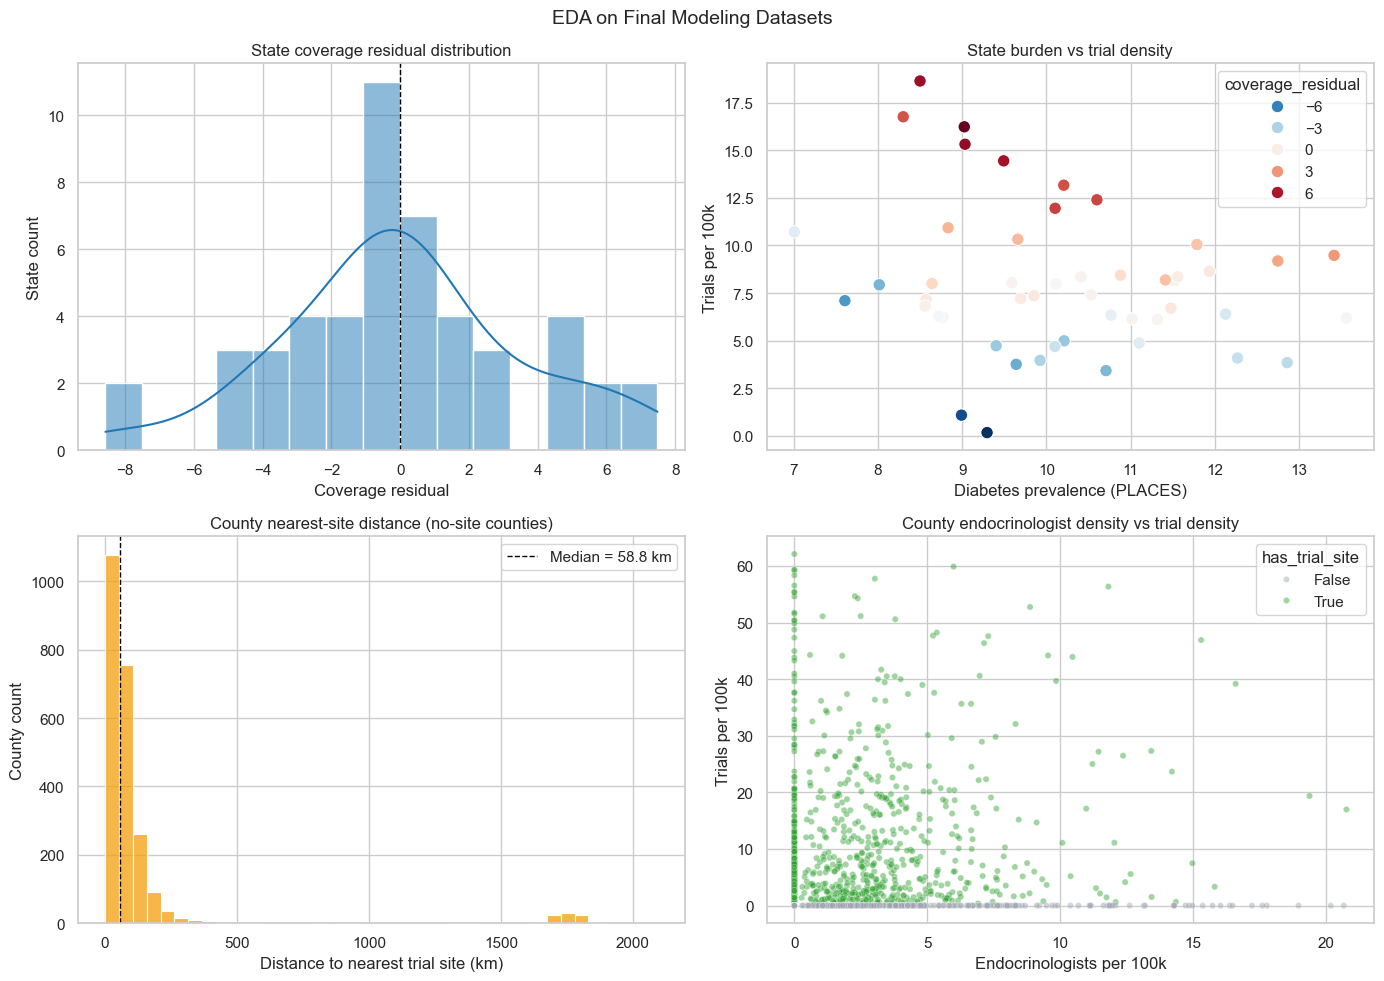

Saved figure: ../results/final_dataset_eda_overview.png
Saved figure: ../../product/results/final_dataset_eda_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

state_resid = state_df["coverage_residual"].dropna()
sns.histplot(state_resid, bins=15, kde=True, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].axvline(0, color="black", lw=1, ls="--")
axes[0, 0].set_title("State coverage residual distribution")
axes[0, 0].set_xlabel("Coverage residual")
axes[0, 0].set_ylabel("State count")

state_scatter_cols = ["places_diabetes", "trials_per_100k", "coverage_residual"]
if all(col in state_df.columns for col in state_scatter_cols):
    state_plot = state_df[state_scatter_cols + ["geo_id"]].dropna().copy()
    sns.scatterplot(
        data=state_plot,
        x="places_diabetes",
        y="trials_per_100k",
        hue="coverage_residual",
        palette="RdBu_r",
        s=80,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("State burden vs trial density")
    axes[0, 1].set_xlabel("Diabetes prevalence (PLACES)")
    axes[0, 1].set_ylabel("Trials per 100k")
else:
    axes[0, 1].text(0.5, 0.5, "Required state columns missing", ha="center", va="center")
    axes[0, 1].set_axis_off()

county_has_site = county_df["has_trial_site"].astype(str).str.lower().isin({"true", "1", "yes"}) if "has_trial_site" in county_df.columns else pd.Series(False, index=county_df.index)
if "dist_nearest_trial_km" in county_df.columns:
    no_site = county_df.loc[~county_has_site, "dist_nearest_trial_km"].dropna()
    sns.histplot(no_site, bins=40, color="#f59e0b", ax=axes[1, 0])
    if not no_site.empty:
        axes[1, 0].axvline(no_site.median(), color="black", lw=1, ls="--", label=f"Median = {no_site.median():.1f} km")
        axes[1, 0].legend(loc="upper right")
    axes[1, 0].set_title("County nearest-site distance (no-site counties)")
    axes[1, 0].set_xlabel("Distance to nearest trial site (km)")
    axes[1, 0].set_ylabel("County count")
else:
    axes[1, 0].text(0.5, 0.5, "dist_nearest_trial_km not available", ha="center", va="center")
    axes[1, 0].set_axis_off()

county_scatter_cols = ["endo_per_100k", "trials_per_100k"]
if all(col in county_df.columns for col in county_scatter_cols):
    county_plot = county_df[county_scatter_cols + ["has_trial_site"]].dropna().copy()
    county_plot = county_plot[
        (county_plot["endo_per_100k"] <= county_plot["endo_per_100k"].quantile(0.99))
        & (county_plot["trials_per_100k"] <= county_plot["trials_per_100k"].quantile(0.99))
    ]
    county_plot["has_trial_site"] = county_plot["has_trial_site"].astype(str).str.lower().isin({"true", "1", "yes"})
    sns.scatterplot(
        data=county_plot,
        x="endo_per_100k",
        y="trials_per_100k",
        hue="has_trial_site",
        palette={True: "#2ca02c", False: "#9ca3af"},
        alpha=0.45,
        s=20,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("County endocrinologist density vs trial density")
    axes[1, 1].set_xlabel("Endocrinologists per 100k")
    axes[1, 1].set_ylabel("Trials per 100k")
else:
    axes[1, 1].text(0.5, 0.5, "Required county columns missing", ha="center", va="center")
    axes[1, 1].set_axis_off()

fig.suptitle("EDA on Final Modeling Datasets", fontsize=14)
fig.tight_layout()
fig.savefig(RESULTS / "final_dataset_eda_overview.png", dpi=200)
fig.savefig(PRODUCT_RESULTS / "final_dataset_eda_overview.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "final_dataset_eda_overview.png")
print("Saved figure:", PRODUCT_RESULTS / "final_dataset_eda_overview.png")

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
state_df = pd.read_csv("../../product/data/modified/state_modeling_final.csv")
county_df = pd.read_csv("../../product/data/modified/county_modeling_final.csv")

In [ ]:
state_df.head(20)

,geo_id,geo_level,trial_count,site_count,trials_per_100k,coverage_residual,industry_pct,pop_total,median_hh_income,gini_index,...,trials_100k_status_active_not_recruiting,trials_100k_status_completed,trials_100k_status_enrolling_by_invitation,trials_100k_status_not_yet_recruiting,trials_100k_status_no_longer_available,trials_100k_status_recruiting,trials_100k_status_suspended,trials_100k_status_terminated,trials_100k_status_unknown,trials_100k_status_withdrawn
0,AK,state,8,9,1.088701,-7.660534,87.500000,734821,86370,0.4304,...,NaN,1.088701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL,state,462,894,9.188376,2.629766,91.125541,5028092,59609,0.4797,...,0.457430,7.259215,0.039777,0.059665,0.019888,0.278436,NaN,0.974525,0.039777,0.059665
2,AR,state,246,394,8.149287,-0.170458,90.243902,3018669,56335,0.4821,...,0.331272,6.691691,0.033127,0.099382,NaN,0.198763,NaN,0.695671,0.066254,0.033127
3,AZ,state,528,1160,7.361674,0.323948,89.393939,7172282,72581,0.4610,...,0.278851,5.660681,0.027885,0.027885,NaN,0.348564,0.069713,0.864439,0.041828,0.041828
4,CA,state,1349,6381,3.427677,-4.174181,80.800593,39356104,91905,0.4895,...,0.121963,2.624752,0.015245,0.033032,NaN,0.200731,0.005082,0.309990,0.058441,0.058441
5,CO,state,458,685,7.936522,-4.295160,80.786026,5770790,87598,0.4560,...,0.311916,6.376943,0.051986,0.051986,NaN,0.398559,NaN,0.589174,0.086643,0.069315
6,CT,state,289,387,8.002621,1.106404,83.391003,3611317,90213,0.4992,...,0.443052,6.258105,NaN,0.055381,NaN,0.387670,0.027691,0.747650,NaN,0.083072
7,DC,state,125,136,18.640385,6.408703,70.400000,670587,101722,0.5171,...,0.447369,14.315816,0.149123,NaN,NaN,1.043862,0.149123,1.789477,0.447369,0.298246
8,DE,state,63,69,6.340356,-1.261502,95.238095,993635,79325,0.4508,...,NaN,5.434591,NaN,NaN,NaN,0.201281,NaN,0.503203,0.100641,0.100641
9,FL,state,1056,5303,4.881086,-1.524661,90.435606,21634529,67917,0.4858,...,0.161778,3.938149,0.004622,0.036978,0.004622,0.226490,0.013867,0.425246,0.023111,0.046222


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

county_df = pd.read_csv("../../product/data/modified/county_modeling_final.csv")
print(f"County dataset: {county_df.shape[0]} rows, {county_df.shape[1]} columns")

County dataset: 3221 rows, 42 columns


In [ ]:
# Target variable
target = "places_diabetes"

# Log-transform skewed variables per modeling plan
county_df["log_trials"] = np.log1p(county_df["trials_per_100k"])
county_df["log_dist"]   = np.log1p(county_df["dist_nearest_trial_km"])
county_df["log_pop"]    = np.log(county_df["pop_total"])

# Predictor groups (per Section 4 and 5 of modeling plan)
access_vars = ["log_trials", "log_dist"]
ses_vars = [
    "log_pop", "pct_poverty", "median_hh_income", "gini_index",
    "pct_uninsured", "pct_unemployed", "pct_bachelors_plus",
    "pct_no_vehicle", "pct_no_internet", "pct_nhblack", "pct_hispanic"
]
all_predictors = access_vars + ses_vars

print(f"Access predictors ({len(access_vars)}): {access_vars}")
print(f"SES predictors    ({len(ses_vars)}): {ses_vars}")

Access predictors (2): ['log_trials', 'log_dist']
SES predictors    (11): ['log_pop', 'pct_poverty', 'median_hh_income', 'gini_index', 'pct_uninsured', 'pct_unemployed', 'pct_bachelors_plus', 'pct_no_vehicle', 'pct_no_internet', 'pct_nhblack', 'pct_hispanic']


In [ ]:
# Missingness summary for selected columns
cols = [target] + all_predictors
miss_n   = county_df[cols].isnull().sum()
miss_pct = (miss_n / len(county_df) * 100).round(2)
miss_table = pd.DataFrame({"missing_n": miss_n, "missing_pct": miss_pct})
print("Missingness in selected columns:")
print(miss_table[miss_table["missing_n"] > 0])

# Complete-case analysis
df_model = county_df[cols].dropna().copy()
print(f"Complete cases: {len(df_model)} / {len(county_df)} ({100*len(df_model)/len(county_df):.1f}%)")

Missingness in selected columns:
                    missing_n  missing_pct
places_diabetes           274         8.51
log_trials                  8         0.25
log_pop                     8         0.25
pct_poverty                 8         0.25
median_hh_income            9         0.28
gini_index                  8         0.25
pct_uninsured               8         0.25
pct_unemployed              8         0.25
pct_bachelors_plus          8         0.25
pct_no_vehicle              8         0.25
pct_no_internet             8         0.25
pct_nhblack                 8         0.25
pct_hispanic                8         0.25
Complete cases: 2947 / 3221 (91.5%)


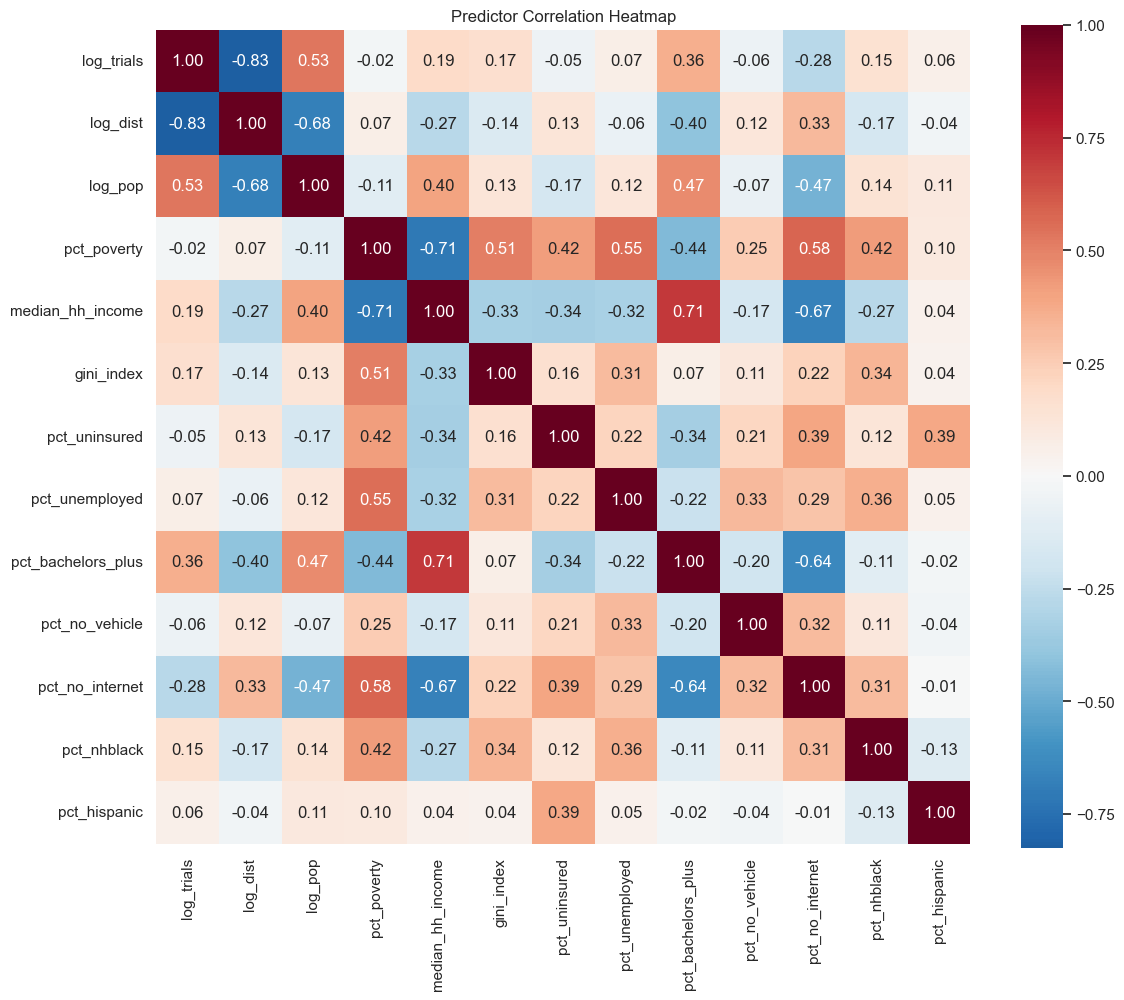

Saved figure: ../../product/results/predictor_correlation_heatmap.png


In [ ]:
# Predictor correlation heatmap to check for multicollinearity
corr = df_model[all_predictors].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Predictor Correlation Heatmap")
plt.tight_layout()
fig.savefig(PRODUCT_RESULTS / "predictor_correlation_heatmap.png", dpi=200)
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "predictor_correlation_heatmap.png")

In [ ]:
# Standardize predictors and fit Elastic Net with cross-validation
X = df_model[all_predictors].values
y = df_model[target].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

cv   = KFold(n_splits=5, shuffle=True, random_state=42)
enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    n_alphas=100,
    cv=cv,
    random_state=42,
    max_iter=10000
)
enet.fit(X_sc, y)

print(f"Best alpha:    {enet.alpha_:.6f}")
print(f"Best l1_ratio: {enet.l1_ratio_:.2f}")

Best alpha:    0.002051
Best l1_ratio: 0.90


In [ ]:
# Cross-validated performance
y_pred_cv = cross_val_predict(enet, X_sc, y, cv=cv)

rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
mae  = mean_absolute_error(y, y_pred_cv)
r2   = r2_score(y, y_pred_cv)

print("5-fold cross-validated performance:")
print(f"  RMSE : {rmse:.4f}  (diabetes prevalence percentage points)")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")

5-fold cross-validated performance:
  RMSE : 0.8591  (diabetes prevalence percentage points)
  MAE  : 0.6557
  R²   : 0.8638


In [ ]:
# Coefficient table sorted by absolute magnitude
coef_df = pd.DataFrame({
    "predictor":   all_predictors,
    "group":       ["Trial Access"] * len(access_vars) + ["Socioeconomic"] * len(ses_vars),
    "coefficient": enet.coef_,
    "abs_coef":    np.abs(enet.coef_)
}).sort_values("abs_coef", ascending=False)

print("Elastic Net Feature Importance — Coefficient Magnitudes (standardized predictors):")
print(coef_df[["predictor", "group", "coefficient"]].to_string(index=False))

Elastic Net Feature Importance — Coefficient Magnitudes (standardized predictors):
         predictor         group  coefficient
       pct_poverty Socioeconomic     0.974821
       pct_nhblack Socioeconomic     0.957739
pct_bachelors_plus Socioeconomic    -0.626198
      pct_hispanic Socioeconomic     0.422031
     pct_uninsured Socioeconomic     0.220181
   pct_no_internet Socioeconomic     0.186703
          log_dist  Trial Access    -0.185216
  median_hh_income Socioeconomic     0.092962
    pct_no_vehicle Socioeconomic     0.074496
    pct_unemployed Socioeconomic     0.067348
        gini_index Socioeconomic    -0.061822
        log_trials  Trial Access    -0.052047
           log_pop Socioeconomic    -0.000000


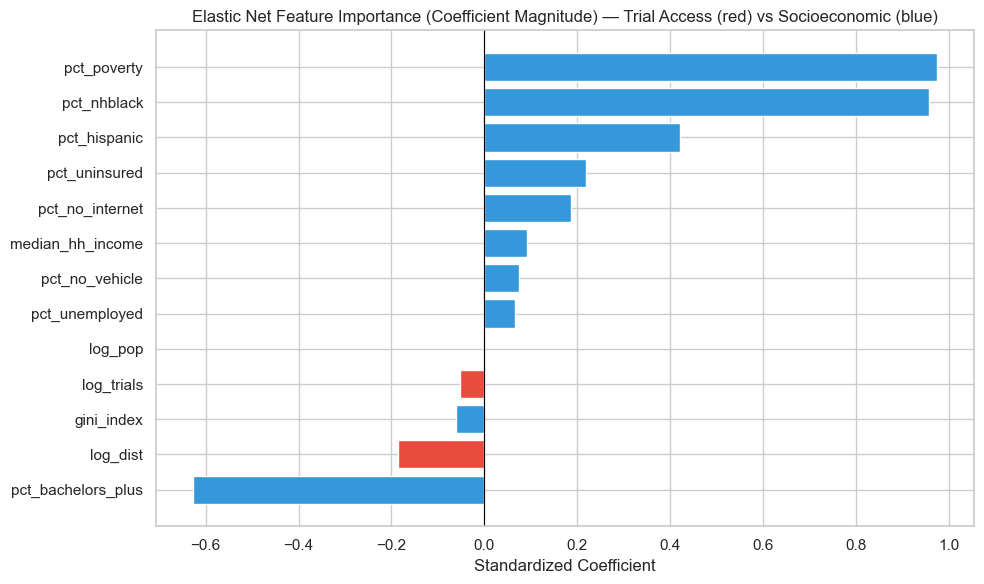

Saved figure: ../../product/results/elastic_net_coefficients.png


In [ ]:
# Coefficient bar plot
coef_plot = coef_df.sort_values("coefficient")
colors = ["#e74c3c" if g == "Trial Access" else "#3498db" for g in coef_plot["group"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_plot["predictor"], coef_plot["coefficient"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized Coefficient")
ax.set_title("Elastic Net Feature Importance (Coefficient Magnitude) — Trial Access (red) vs Socioeconomic (blue)")
plt.tight_layout()
fig.savefig(PRODUCT_RESULTS / "elastic_net_coefficients.png", dpi=200)
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "elastic_net_coefficients.png")

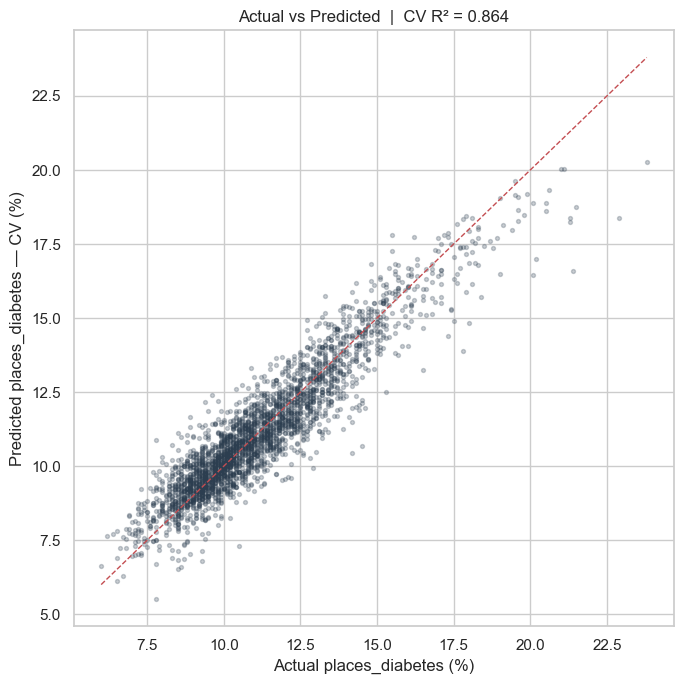

Saved figure: ../../product/results/elastic_net_actual_vs_predicted.png


In [ ]:
# Actual vs predicted scatter
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, y_pred_cv, alpha=0.25, s=8, color="#2c3e50")
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1)
ax.set_xlabel("Actual places_diabetes (%)")
ax.set_ylabel("Predicted places_diabetes — CV (%)")
ax.set_title(f"Actual vs Predicted  |  CV R² = {r2:.3f}")
plt.tight_layout()
fig.savefig(PRODUCT_RESULTS / "elastic_net_actual_vs_predicted.png", dpi=200)
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "elastic_net_actual_vs_predicted.png")

In [ ]:
X_raw = df_model[all_predictors].values   # no standardization for trees

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "n_estimators":     [200, 500, 800],
    "max_depth":        [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_raw, y)

print("Random Forest \u2014 Best hyperparameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Best CV R\u00b2: {rf_search.best_score_:.4f}")
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest — Best hyperparameters:
  n_estimators: 500
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 30
  Best CV R²: 0.8820


In [ ]:
# 5-fold CV performance of best-tuned Random Forest
y_pred_rf = cross_val_predict(best_rf, X_raw, y, cv=cv)
rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))
mae_rf  = mean_absolute_error(y, y_pred_rf)
r2_rf   = r2_score(y, y_pred_rf)

print("Random Forest (tuned) \u2014 5-fold CV:")
print(f"  RMSE : {rmse_rf:.4f}  (diabetes prevalence percentage points)")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  R\u00b2   : {r2_rf:.4f}")

Random Forest (tuned) — 5-fold CV:
  RMSE : 0.7994  (diabetes prevalence percentage points)
  MAE  : 0.6055
  R²   : 0.8821


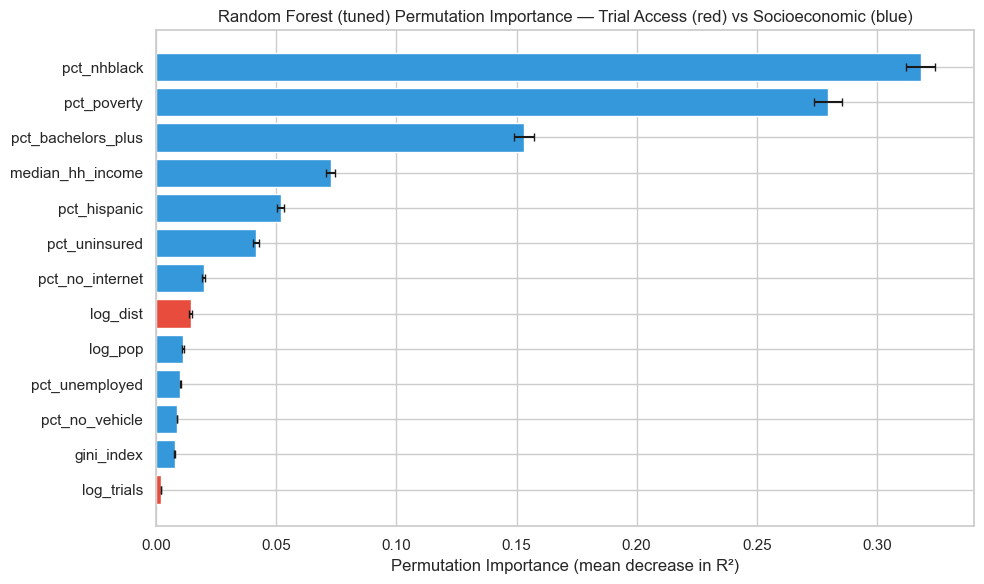

Saved figure: ../../product/results/rf_permutation_importance.png


In [ ]:
from sklearn.inspection import permutation_importance

# Fit best RF on full data for importance estimation
best_rf.fit(X_raw, y)
perm = permutation_importance(best_rf, X_raw, y, n_repeats=20, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    "predictor":  all_predictors,
    "group":      ["Trial Access"] * len(access_vars) + ["Socioeconomic"] * len(ses_vars),
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=True)

colors_rf = ["#e74c3c" if g == "Trial Access" else "#3498db" for g in imp_df["group"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df["predictor"], imp_df["importance"], xerr=imp_df["std"],
        color=colors_rf, capsize=3)
ax.set_xlabel("Permutation Importance (mean decrease in R\u00b2)")
ax.set_title("Random Forest (tuned) Permutation Importance \u2014 Trial Access (red) vs Socioeconomic (blue)")
plt.tight_layout()
fig.savefig(PRODUCT_RESULTS / "rf_permutation_importance.png", dpi=200)
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "rf_permutation_importance.png")

In [ ]:
from xgboost import XGBRegressor

xgb_param_dist = {
    "n_estimators":     [200, 500, 800],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 5, 7],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
xgb_search.fit(X_raw, y)

print("XGBoost \u2014 Best hyperparameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Best CV R\u00b2: {xgb_search.best_score_:.4f}")
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/chenzhang/Alex's Codebases/JSC370-Midterm-Proj/.venv-option-c/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost — Best hyperparameters:
  subsample: 0.8
  n_estimators: 800
  min_child_weight: 3
  max_depth: 7
  learning_rate: 0.01
  colsample_bytree: 0.6
  Best CV R²: 0.8916


In [ ]:
# 5-fold CV performance of best-tuned XGBoost
y_pred_xgb = cross_val_predict(best_xgb, X_raw, y, cv=cv)
rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))
mae_xgb  = mean_absolute_error(y, y_pred_xgb)
r2_xgb   = r2_score(y, y_pred_xgb)

print("XGBoost (tuned) \u2014 5-fold CV:")
print(f"  RMSE : {rmse_xgb:.4f}  (diabetes prevalence percentage points)")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  R\u00b2   : {r2_xgb:.4f}")

XGBoost (tuned) — 5-fold CV:
  RMSE : 0.7665  (diabetes prevalence percentage points)
  MAE  : 0.5775
  R²   : 0.8916


In [ ]:
# SES-only feature matrices
X_ses_sc = scaler.fit_transform(df_model[ses_vars].values)
X_ses_raw = df_model[ses_vars].values

# --- Elastic Net (SES-only) ---
enet_ses = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    n_alphas=100, cv=cv, random_state=42, max_iter=10000
)
enet_ses.fit(X_ses_sc, y)
y_pred_ses_enet = cross_val_predict(enet_ses, X_ses_sc, y, cv=cv)
r2_ses_enet  = r2_score(y, y_pred_ses_enet)
rmse_ses_enet = np.sqrt(mean_squared_error(y, y_pred_ses_enet))
mae_ses_enet  = mean_absolute_error(y, y_pred_ses_enet)

# --- Random Forest (SES-only) ---
rf_ses = RandomForestRegressor(**rf_search.best_params_, random_state=42, n_jobs=-1)
y_pred_ses_rf = cross_val_predict(rf_ses, X_ses_raw, y, cv=cv)
r2_ses_rf  = r2_score(y, y_pred_ses_rf)
rmse_ses_rf = np.sqrt(mean_squared_error(y, y_pred_ses_rf))
mae_ses_rf  = mean_absolute_error(y, y_pred_ses_rf)

# --- XGBoost (SES-only) ---
xgb_ses = XGBRegressor(**xgb_search.best_params_, random_state=42, verbosity=0)
y_pred_ses_xgb = cross_val_predict(xgb_ses, X_ses_raw, y, cv=cv)
r2_ses_xgb  = r2_score(y, y_pred_ses_xgb)
rmse_ses_xgb = np.sqrt(mean_squared_error(y, y_pred_ses_xgb))
mae_ses_xgb  = mean_absolute_error(y, y_pred_ses_xgb)

print("SES-only baseline (5-fold CV):")
print(f"  Elastic Net  — R²: {r2_ses_enet:.4f}  RMSE: {rmse_ses_enet:.4f}  MAE: {mae_ses_enet:.4f}")
print(f"  Random Forest — R²: {r2_ses_rf:.4f}  RMSE: {rmse_ses_rf:.4f}  MAE: {mae_ses_rf:.4f}")
print(f"  XGBoost       — R²: {r2_ses_xgb:.4f}  RMSE: {rmse_ses_xgb:.4f}  MAE: {mae_ses_xgb:.4f}")

SES-only baseline (5-fold CV):
  Elastic Net  — R²: 0.8618  RMSE: 0.8655  MAE: 0.6617
  Random Forest — R²: 0.8800  RMSE: 0.8064  MAE: 0.6113
  XGBoost       — R²: 0.8886  RMSE: 0.7771  MAE: 0.5877


In [ ]:
model_comparison = pd.DataFrame({
    "Model":         ["Elastic Net", "Elastic Net",
                      "Random Forest", "Random Forest",
                      "XGBoost", "XGBoost"],
    "Features":      ["SES-only", "Full",
                      "SES-only", "Full",
                      "SES-only", "Full"],
    "RMSE":          [rmse_ses_enet, rmse,
                      rmse_ses_rf, rmse_rf,
                      rmse_ses_xgb, rmse_xgb],
    "MAE":           [mae_ses_enet, mae,
                      mae_ses_rf, mae_rf,
                      mae_ses_xgb, mae_xgb],
    "R²":            [r2_ses_enet, r2,
                      r2_ses_rf, r2_rf,
                      r2_ses_xgb, r2_xgb],
})
print(model_comparison.to_string(index=False))
print()

# Delta R² summary
for model_name, r2_ses, r2_full in [
    ("Elastic Net",    r2_ses_enet, r2),
    ("Random Forest",  r2_ses_rf,   r2_rf),
    ("XGBoost",        r2_ses_xgb,  r2_xgb),
]:
    delta = r2_full - r2_ses
    print(f"  {model_name:15s}  ΔR² = {delta:+.4f}")

        Model Features     RMSE      MAE       R²
  Elastic Net SES-only 0.865486 0.661683 0.861775
  Elastic Net     Full 0.859103 0.655659 0.863807
Random Forest SES-only 0.806427 0.611305 0.879996
Random Forest     Full 0.799368 0.605492 0.882088
      XGBoost SES-only 0.777108 0.587709 0.888563
      XGBoost     Full 0.766500 0.577527 0.891585

  Elastic Net      ΔR² = +0.0020
  Random Forest    ΔR² = +0.0021
  XGBoost          ΔR² = +0.0030


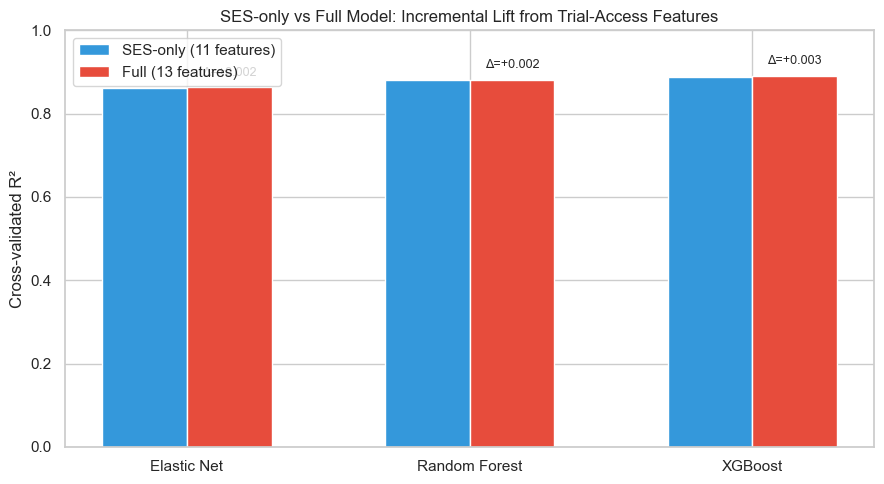

Saved figure: ../../product/results/model_comparison_cv.png


In [ ]:
# Grouped bar chart: SES-only vs Full R² for each model
fig, ax = plt.subplots(figsize=(9, 5))
models = ["Elastic Net", "Random Forest", "XGBoost"]
r2_ses_vals  = [r2_ses_enet, r2_ses_rf, r2_ses_xgb]
r2_full_vals = [r2,          r2_rf,     r2_xgb]

x = np.arange(len(models))
width = 0.3
bars_ses  = ax.bar(x - width/2, r2_ses_vals,  width, label="SES-only (11 features)", color="#3498db")
bars_full = ax.bar(x + width/2, r2_full_vals, width, label="Full (13 features)",     color="#e74c3c")

ax.set_ylabel("Cross-validated R²")
ax.set_title("SES-only vs Full Model: Incremental Lift from Trial-Access Features")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

# Annotate delta R²
for i in range(len(models)):
    delta = r2_full_vals[i] - r2_ses_vals[i]
    mid_x = x[i] + width/2
    mid_y = max(r2_ses_vals[i], r2_full_vals[i]) + 0.02
    ax.text(mid_x, mid_y, f"Δ={delta:+.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig.savefig(PRODUCT_RESULTS / "model_comparison_cv.png", dpi=200)
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "model_comparison_cv.png")

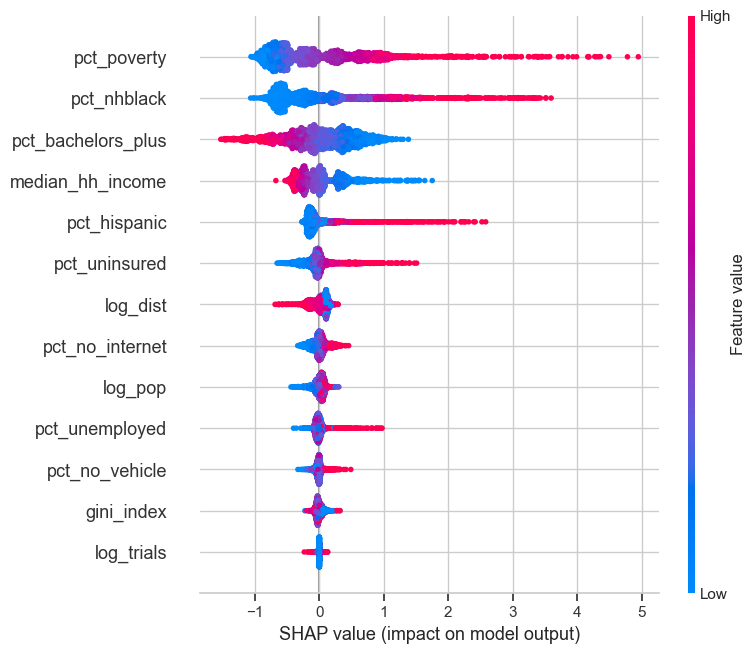

Saved figure: ../../product/results/shap_summary_plot.png


In [ ]:
import shap

# Refit best XGBoost on full data for SHAP attribution
best_xgb.fit(X_raw, y)
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_raw)

shap.summary_plot(shap_values, X_raw, feature_names=all_predictors, show=False)
plt.tight_layout()
plt.savefig(PRODUCT_RESULTS / "shap_summary_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "shap_summary_plot.png")

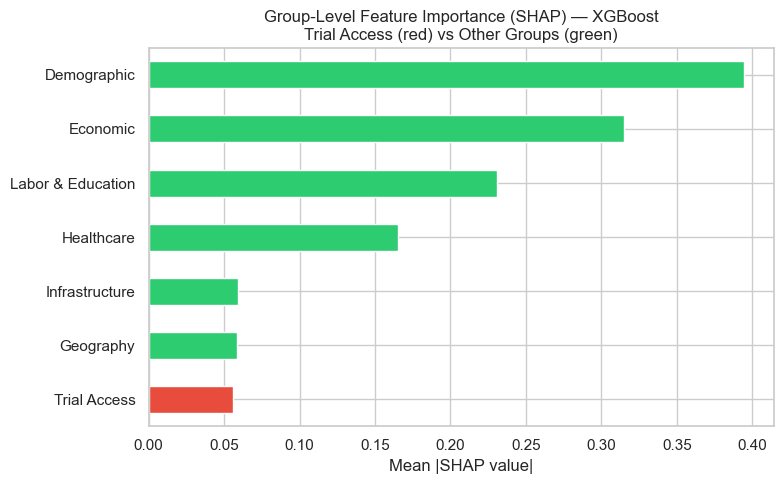

Saved figure: ../../product/results/shap_group_importance.png


In [ ]:
group_map = {
    "Trial Access":      ["log_trials", "log_dist"],
    "Economic":          ["pct_poverty", "median_hh_income", "gini_index"],
    "Healthcare":        ["pct_uninsured"],
    "Labor & Education": ["pct_unemployed", "pct_bachelors_plus"],
    "Infrastructure":    ["pct_no_vehicle", "pct_no_internet"],
    "Demographic":       ["pct_nhblack", "pct_hispanic"],
    "Geography":         ["log_pop"],
}

idx_map = {v: i for i, v in enumerate(all_predictors)}
group_imp = {
    g: np.abs(shap_values[:, [idx_map[v] for v in vars_]]).mean()
    for g, vars_ in group_map.items()
}

group_df = pd.Series(group_imp).sort_values(ascending=True)
colors_shap = ["#e74c3c" if g == "Trial Access" else "#2ecc71"
              for g in group_df.index]

group_df.plot(kind="barh", color=colors_shap, figsize=(8, 5))
plt.xlabel("Mean |SHAP value|")
plt.title(
    "Group-Level Feature Importance (SHAP) \u2014 XGBoost\n"
    "Trial Access (red) vs Other Groups (green)"
)
plt.tight_layout()
plt.savefig(PRODUCT_RESULTS / "shap_group_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", PRODUCT_RESULTS / "shap_group_importance.png")